In [1]:
pip install psycopg2-binary phik sweetviz catboost -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.3.2 -> 24.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Предсказание температуры сплава стали

Чтобы оптимизировать производственные расходы, металлургический комбинат «Стальная птица» решил уменьшить потребление электроэнергии на этапе обработки стали.

### Цель работы
Построить модель, которая будет предсказывать температуру сплава.

### Описание данных

Данные хранятся в базе данных PostgreSQL. Она состоит из нескольких таблиц:
- steel.data_arc — данные об электродах;
- steel.data_bulk — данные об объёме сыпучих материалов;
- steel.data_bulk_time — данные о времени подачи сыпучих материалов;
- steel.data_gas — данные о продувке сплава газом;
- steel.data_temp — данные об измерениях температуры;
- steel.data_wire — данные об объёме проволочных материалов;
- steel.data_wire_time — данные о времени подачи проволочных материалов.

**Таблица steel.data_arc**
- key — номер партии;
- BeginHeat — время начала нагрева;
- EndHeat — время окончания нагрева;
- ActivePower — значение активной мощности;
- ReactivePower — значение реактивной мощности.

**Таблица steel.data_bulk**
- key — номер партии;
- Bulk1 … Bulk15 — объём подаваемого материала.

**Таблица steel.data_bulk_time**
- key — номер партии;
- Bulk1 … Bulk15 — время подачи материала.

**Таблица steel.data_gas**
- key — номер партии;
- gas — объём подаваемого газа.

**Таблица steel.data_temp**
- key — номер партии;
- MesaureTime — время замера;
- Temperature — значение температуры.

**Таблица steel.data_wire**
- key — номер партии;
- Wire1 … Wire15 — объём подаваемых проволочных материалов.

**Таблица steel.data_wire_time**
- key — номер партии;
- Wire1 … Wire15 — время подачи проволочных материалов.

Во всех файлах столбец key содержит номер партии. В таблицах может быть несколько строк с одинаковым значением key: они соответствуют разным итерациям обработки.

### План работы
1. Загрузка и знакомство с данными.
2. Исследовательский анализ данных. Проверить:
  - Проверить все ли таблицы содержат данные.
  - Проверить соответствует ли количество таблиц условию задачи.
  - Для каждой таблицы проверить наличие пропусков и аномалий, изучить распределение признаков.
3. Объединить таблицы по ключу.
4. Подготовить данные для обучения моделей.
5. Обучить несколько моделей:
  - случайный лес,
  - CatBoost,
  - нейронная сеть.

  Найти лучшую модель для прогноза последней измеренной температуры. Оценить её качество метрикой MAE.
6. Тестирование лучшей модели:
  - Проверить качество лучшей модели на тестовой выборке. Значение метрики MAE должно быть менее 6.8.
  - Сравнить результаты лучшей и константной моделей.
  - Проанализировать важность основных признаков.
  - Для одного из важных признаков показать график зависимости входного и целевого признаков.
7. Общий вывод.

## 1. Загрузка данных

In [2]:
import psycopg2 as ps
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import phik
import sweetviz as sv
import torch
import torch.nn as nn

from datetime import datetime, date, time
from phik.report import plot_correlation_matrix
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam

Для начала зададим константу ` RANDOM_STATE`.

In [3]:
 RANDOM_STATE = 60624

Объявим конфигурацию для подключения к серверу.

In [ ]:
db_config = {
'user': # имя пользователя
'pwd': # пароль
'host': # хост подключения
'port': # порт подключения
'db': # название базы данных,
}

Формируем подключение.

In [5]:
connection = ps.connect(
    host=db_config['host'],
    port=db_config['port'],
    dbname=db_config['db'],
    user=db_config['user'],
    password=db_config['pwd'])

In [6]:
cursor = connection.cursor()
cursor.execute("""SELECT table_schema, table_name
                      FROM information_schema.tables
                      WHERE table_schema != 'telecom'
                      AND table_schema != 'pg_catalog'
                      AND table_schema != 'information_schema'
                      AND table_type='BASE TABLE'
                      ORDER BY table_schema, table_name""")
tables = cursor.fetchall()
tables

[('steel', 'data_arc'),
 ('steel', 'data_bulk'),
 ('steel', 'data_bulk_time'),
 ('steel', 'data_gas'),
 ('steel', 'data_temp'),
 ('steel', 'data_wire'),
 ('steel', 'data_wire_time')]

**Вывод по первому шагу:** успешно подключились к серверу и смогли получить названия всех таблиц, их количество и название соответствует представленным в описании. Далее перейдем к их исследованию.

## 2. Исследовательский анализ данных

In [7]:
#функция для чтения SQL данных
def read_sql(data):
    query = f'''
    SELECT *
      FROM steel.{data}
    '''
    df = pd.read_sql_query(query, con=connection)
    return df

In [8]:
# функция для поиска выбросов и аномалий при помощи боксплота
def box_plot(data, num_cols, n=3):
    if n > 1:
        x = len(num_cols) // n
        y = len(num_cols) // x
        fig, axs = plt.subplots(x, y)
        ax = axs.ravel()
        plt.figure
        fig.suptitle('Распределение числовых признаков', fontsize=15)
        fig.set_size_inches(15, y*x+2)
        for i, num in enumerate(num_cols):
            ax[i].boxplot(data[num])
            ax[i].set_title(num)
    else:
        plt.figure(figsize=(5,5))
        data.boxplot()
        plt.title('Распределение числовых признаков', fontsize=15)
        plt.ylabel('count')
    plt.show()

In [9]:
# функция для построения распределения числовых признаков
def hist_plot(data, num_cols, n=3):
    if n > 1:
        x = len(num_cols) // n
        y = len(num_cols) // x
        fig, axs = plt.subplots(x, y)
        ax = axs.ravel()
        plt.figure
        fig.suptitle('Распределение числовых признаков', fontsize=15)
        fig.set_size_inches(25, y*x+2)
        for i, num in enumerate(num_cols):
            ax[i].hist(data[num], bins=100, edgecolor = 'black')
            ax[i].set_title(num)
    else:
        plt.figure(figsize=(5,5))
        data.hist(bins=100, edgecolor = 'black')
        plt.title('Распределение числовых признаков', fontsize=15)
        plt.xlabel(data.columns[0])
        plt.ylabel('count')
    plt.show()

### **Таблица `steel.data_arc`**

In [10]:
df_arc = read_sql('data_arc')
df_arc.info()
df_arc.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14876 entries, 0 to 14875
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   key            14876 non-null  int64  
 1   BeginHeat      14876 non-null  object 
 2   EndHeat        14876 non-null  object 
 3   ActivePower    14876 non-null  float64
 4   ReactivePower  14876 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 581.2+ KB


,key,BeginHeat,EndHeat,ActivePower,ReactivePower
0,1,11:02:14,11:06:02,0.976059,0.687084
1,1,11:07:28,11:10:33,0.805607,0.520285
2,1,11:11:44,11:14:36,0.744363,0.498805
3,1,11:18:14,11:24:19,1.659363,1.062669
4,1,11:26:09,11:28:37,0.692755,0.414397
5,2,11:34:14,11:36:31,0.438063,0.283043
6,2,11:38:50,11:44:28,1.296415,0.892914
7,2,11:46:19,11:48:25,0.490377,0.305281
8,2,11:49:48,11:53:18,0.827743,0.516874
9,3,12:06:54,12:11:34,1.062053,0.671494


Пропуски в таблице остуствуют.

Здесь и для таблиц далее переименуем названия столбцов в общепринятый формат.

In [11]:
df_arc.columns = ['key', 'begin_heat', 'end_heat', 'active_power', 'reactive_power']

Рассчитаем продолжительность нагрева.

In [12]:
def duration(data):
    data["heat_duration"] = datetime.combine(
    date.today(), data["end_heat"]
    ) - datetime.combine(date.today(), data["begin_heat"])
    data['heat_duration'] = data['heat_duration'].total_seconds()
    return data

In [13]:
df_arc = df_arc.apply(duration, axis=1)

Теперь рассмотрим распределение признаков при помощи гистограмы и боксплота, выполним поиск возможных аномалий.

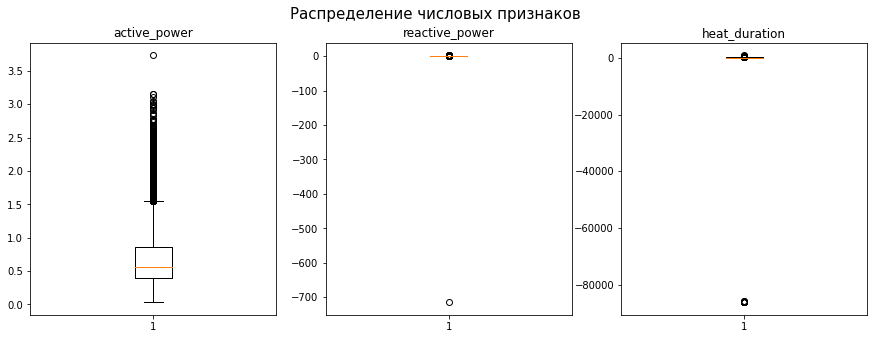

In [14]:
num_cols = ['active_power', 'reactive_power', 'heat_duration']
box_plot(data=df_arc, num_cols=num_cols)

Реактивная мощность меньше нуля похожа на ошибку при сборе информации. Продолжительность нагрева меньше нуля связана с ошибкой в данных либо с ошибкой при обработке, возможно были представлены начало и конец нагрева в разных днях, тем не менее это тоже считается аномалией, т.к. таких длинных циклов быть не должно.

Далее устраним выбросы и аномалии.

In [15]:
df_arc = df_arc.query('(reactive_power >= 0) & (heat_duration >=0)')

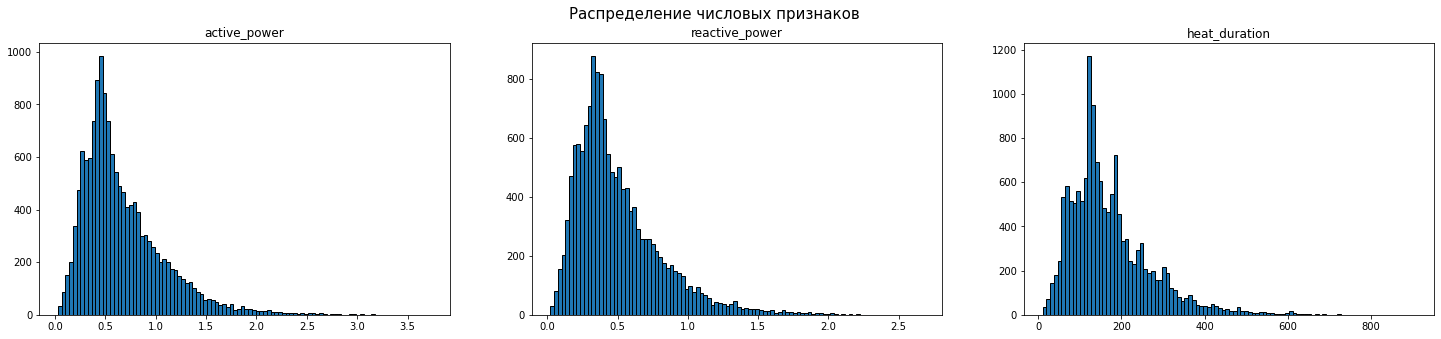

In [16]:
hist_plot(data=df_arc, num_cols=num_cols)

Все числовые признаки после удаления аномалий имеют гамма-распределение.

Первый признак мы уже создали - продолжительность нагрева. Далее создадим еще несколько:
- количество запусков нагрева электродами(посчитаем при группировке);
- полную мощность, которая равна квадратному корню из суммы квадратов активной и реактивной мощностей: $ S = sqrt(P^2 + Q^2) $
- потребление электроэнергии, равное произведению полной мощности на время нагрева.

In [17]:
df_arc['full_power'] = np.sqrt(pow(df_arc['active_power'], 2) + pow(df_arc['reactive_power'], 2))
df_arc['consumption'] = df_arc['full_power'] * df_arc['heat_duration']

От столбцов с началом и окончанием нагрева можем избавиться.

In [18]:
df_arc = df_arc.drop(['begin_heat', 'end_heat'], axis=1)

Теперь выполним аггрегирование наблюдений по ключу.

In [19]:
df_arc = (
    df_arc.groupby("key")
    .agg(
        {
            "key": "count",
            #"begin_heat": "min",
            #"end_heat": "max",
            "active_power": "sum",
            "reactive_power": "sum",
            "full_power": "sum",
            "heat_duration": "sum",
            "consumption": "sum",
        }
    )
    .rename(columns={"key": "heat_count"})
)


In [20]:
df_arc.info()
df_arc.head(10)

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3214 entries, 1 to 3241
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   heat_count      3214 non-null   int64  
 1   active_power    3214 non-null   float64
 2   reactive_power  3214 non-null   float64
 3   full_power      3214 non-null   float64
 4   heat_duration   3214 non-null   float64
 5   consumption     3214 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 175.8 KB


,heat_count,active_power,reactive_power,full_power,heat_duration,consumption
key,,,,,,
1,5,4.878147,3.183241,5.826395,1098.0,1442.377754
2,4,3.052598,1.998112,3.649216,811.0,881.233565
3,5,2.525882,1.599076,2.989534,655.0,525.066777
4,4,3.209250,2.060298,3.814962,741.0,796.911309
5,4,3.347173,2.252643,4.035758,869.0,1199.137958
6,4,3.955108,2.689175,4.786837,952.0,1410.747219
7,4,2.547375,1.561295,2.987777,673.0,729.780631
8,4,3.762755,2.680698,4.627389,913.0,1550.542227
9,5,2.081951,1.478671,2.555348,625.0,406.460647


В результате получили 3214 строк и 6 столбцов агрегированных данных.

### **Таблица `steel.data_bulk`**

In [21]:
df_bulk = read_sql('data_bulk')
# здесь и далее будем преобразовывать столбец key в индекс для единообразия таблиц и упрощения их объединения
df_bulk = df_bulk.set_index('key')
df_bulk.info()
df_bulk.head(10)

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3129 entries, 1 to 3241
Data columns (total 15 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Bulk 1   252 non-null    float64
 1   Bulk 2   22 non-null     float64
 2   Bulk 3   1298 non-null   float64
 3   Bulk 4   1014 non-null   float64
 4   Bulk 5   77 non-null     float64
 5   Bulk 6   576 non-null    float64
 6   Bulk 7   25 non-null     float64
 7   Bulk 8   1 non-null      float64
 8   Bulk 9   19 non-null     float64
 9   Bulk 10  176 non-null    float64
 10  Bulk 11  177 non-null    float64
 11  Bulk 12  2450 non-null   float64
 12  Bulk 13  18 non-null     float64
 13  Bulk 14  2806 non-null   float64
 14  Bulk 15  2248 non-null   float64
dtypes: float64(15)
memory usage: 391.1 KB


,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
key,,,,,,,,,,,,,,,
1,NaN,NaN,NaN,43.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,206.0,NaN,150.0,154.0
2,NaN,NaN,NaN,73.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,206.0,NaN,149.0,154.0
3,NaN,NaN,NaN,34.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,205.0,NaN,152.0,153.0
4,NaN,NaN,NaN,81.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,207.0,NaN,153.0,154.0
5,NaN,NaN,NaN,78.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,203.0,NaN,151.0,152.0
6,NaN,NaN,NaN,117.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,204.0,NaN,201.0,154.0
7,NaN,NaN,NaN,117.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,204.0,NaN,152.0,154.0
8,NaN,NaN,NaN,99.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,410.0,NaN,252.0,153.0
9,NaN,NaN,NaN,117.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,107.0,NaN,99.0,203.0


In [22]:
df_bulk.columns = [column.lower().replace(' ', '_') for column in df_bulk.columns]

В таблице большое количество пропусков, что свидетельствует о недобавлении данного сыпучего материала. Можно заполнить данные пропуски нулями.



In [23]:
df_bulk = df_bulk.fillna(0)

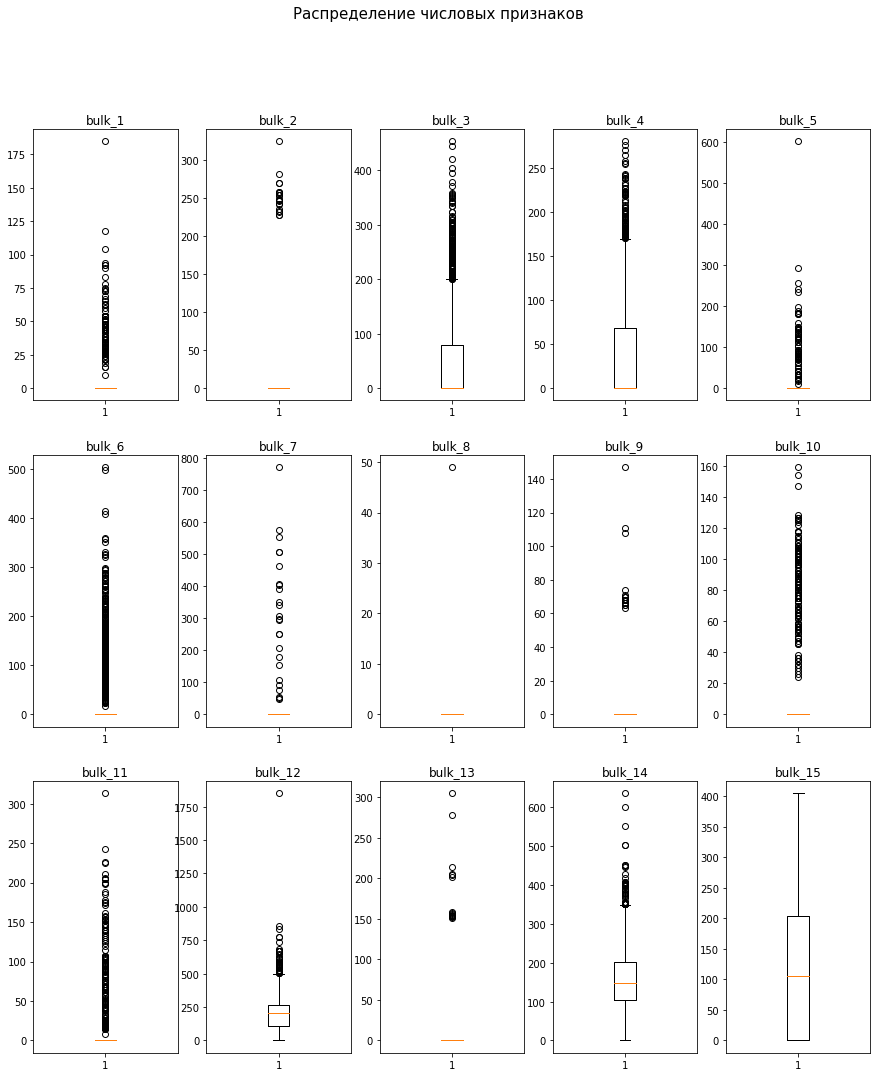

In [24]:
box_plot(data=df_bulk, num_cols=df_bulk.columns, n=5)

Большинство сыпучих материалов редко добавляется в сплавы, поэтому их добавление выглядит, как выброс, такие данные сохраним.

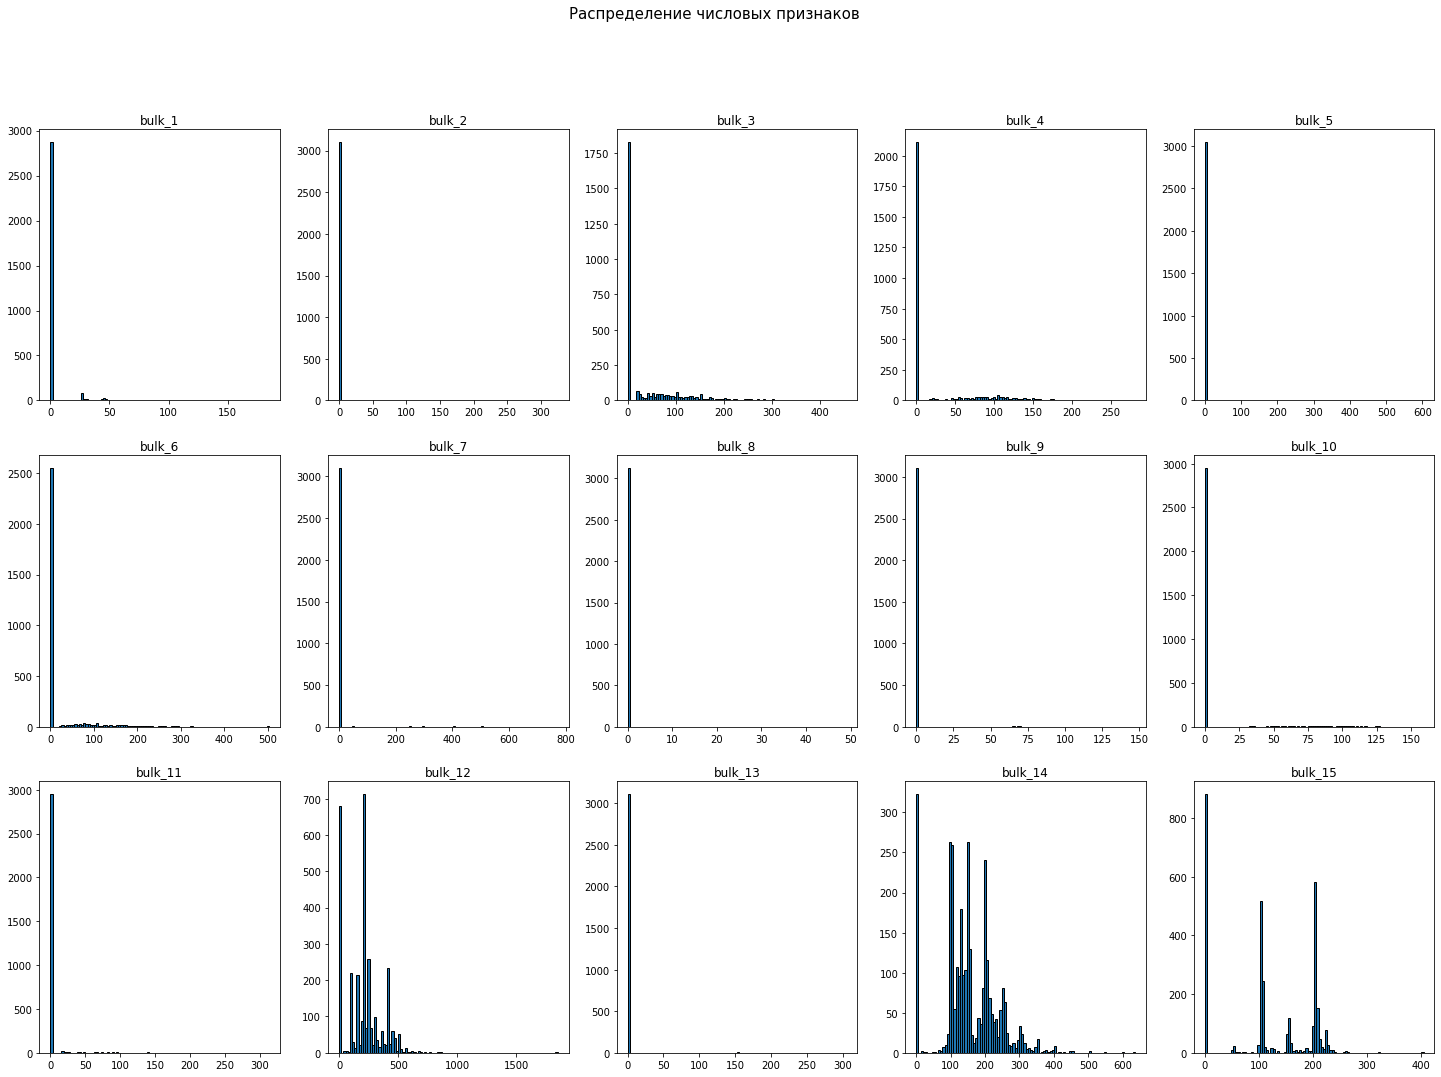

In [25]:
hist_plot(data=df_bulk, num_cols=df_bulk.columns, n=5)

Добавление сыпучих материалов не имеет каких-то характерных распределений.

In [26]:
df_bulk.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3129 entries, 1 to 3241
Data columns (total 15 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   bulk_1   3129 non-null   float64
 1   bulk_2   3129 non-null   float64
 2   bulk_3   3129 non-null   float64
 3   bulk_4   3129 non-null   float64
 4   bulk_5   3129 non-null   float64
 5   bulk_6   3129 non-null   float64
 6   bulk_7   3129 non-null   float64
 7   bulk_8   3129 non-null   float64
 8   bulk_9   3129 non-null   float64
 9   bulk_10  3129 non-null   float64
 10  bulk_11  3129 non-null   float64
 11  bulk_12  3129 non-null   float64
 12  bulk_13  3129 non-null   float64
 13  bulk_14  3129 non-null   float64
 14  bulk_15  3129 non-null   float64
dtypes: float64(15)
memory usage: 391.1 KB


В результате получили 2989 строк и 15 столбцов обработанных данных.

### **Таблица `steel.data_bulk_time`**

In [27]:
df_bulk_time = read_sql('data_bulk_time')
df_bulk_time = df_bulk_time.set_index('key')
df_bulk_time.info()
df_bulk_time.head(10)

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3129 entries, 1 to 3241
Data columns (total 15 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Bulk 1   252 non-null    object
 1   Bulk 2   22 non-null     object
 2   Bulk 3   1298 non-null   object
 3   Bulk 4   1014 non-null   object
 4   Bulk 5   77 non-null     object
 5   Bulk 6   576 non-null    object
 6   Bulk 7   25 non-null     object
 7   Bulk 8   1 non-null      object
 8   Bulk 9   19 non-null     object
 9   Bulk 10  176 non-null    object
 10  Bulk 11  177 non-null    object
 11  Bulk 12  2450 non-null   object
 12  Bulk 13  18 non-null     object
 13  Bulk 14  2806 non-null   object
 14  Bulk 15  2248 non-null   object
dtypes: object(15)
memory usage: 391.1+ KB


,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
key,,,,,,,,,,,,,,,
1,None,None,None,11:21:30,None,None,None,None,None,None,None,11:03:52,None,11:03:52,11:03:52
2,None,None,None,11:46:38,None,None,None,None,None,None,None,11:40:20,None,11:40:20,11:40:20
3,None,None,None,12:31:06,None,None,None,None,None,None,None,12:09:40,None,12:09:40,12:09:40
4,None,None,None,12:48:43,None,None,None,None,None,None,None,12:41:24,None,12:41:24,12:41:24
5,None,None,None,13:18:50,None,None,None,None,None,None,None,13:12:56,None,13:12:56,13:12:56
6,None,None,None,13:59:24,None,None,None,None,None,None,None,13:53:27,None,13:53:27,13:53:27
7,None,None,None,14:29:14,None,None,None,None,None,None,None,14:22:19,None,14:22:19,14:22:19
8,None,None,None,15:04:05,None,None,None,None,None,None,None,14:55:46,None,14:55:46,14:55:46
9,None,None,None,15:47:34,None,None,None,None,None,None,None,15:41:00,None,15:41:00,15:41:00


Наличие данных в таблице со временем подачи соответствует наличию факта подачи в предыдущей таблице. Пропуски также можно заменить нулями.

In [28]:
df_bulk_time.columns = df_bulk.columns

In [29]:
df_bulk_time = df_bulk_time.fillna(0)

### **Таблица `steel.data_gas`**

In [30]:
df_gas = read_sql('data_gas')
df_gas = df_gas.set_index('key')
df_gas.info()
df_gas.head(10)

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3239 entries, 1 to 3241
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   gas     3239 non-null   float64
dtypes: float64(1)
memory usage: 50.6 KB


,gas
key,
1,29.749986
2,12.555561
3,28.554793
4,18.841219
5,5.413692
6,11.273392
7,9.836267
8,15.171553
9,8.216623


Вероятно, пропуски в таблице означают, что газ не подавался. Заполним их нулями.

In [31]:
df_gas = df_gas.fillna(0)

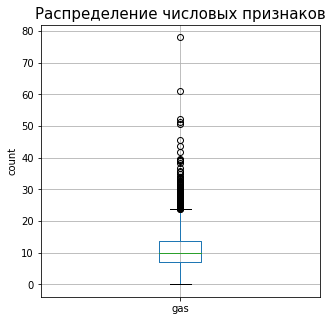

In [32]:
box_plot(data=df_gas, num_cols=df_gas.columns, n=1)

<Figure size 360x360 with 0 Axes>

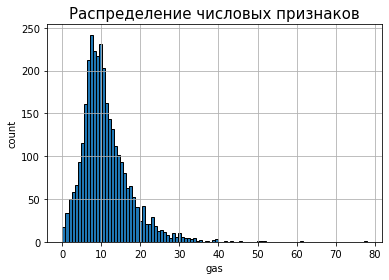

In [33]:
hist_plot(data=df_gas, num_cols=df_gas.columns, n=1)

Признак объема газа имеет гамма-распределение.

In [34]:
df_gas.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3239 entries, 1 to 3241
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   gas     3239 non-null   float64
dtypes: float64(1)
memory usage: 50.6 KB


В результате получили 3193 строки и 1 столбец обработанных данных.

### **Таблица `steel.data_temp`**

In [35]:
df_temp = read_sql('data_temp')
df_temp.info()
df_temp.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15907 entries, 0 to 15906
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   key          15907 non-null  int64  
 1   MesaureTime  15907 non-null  object 
 2   Temperature  13006 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 372.9+ KB


,key,MesaureTime,Temperature
0,1,11:16:18,1571.0
1,1,11:25:53,1604.0
2,1,11:29:11,1618.0
3,1,11:30:01,1601.0
4,1,11:30:39,1613.0
5,2,11:37:27,1581.0
6,2,11:38:00,1577.0
7,2,11:49:38,1589.0
8,2,11:55:50,1604.0
9,2,11:58:24,1608.0


In [36]:
df_temp.columns = ['key', 'mesaure_time', 'temperature']

Пропуски в таблице свидетельствуют о неправильности измерений, избавимся от них. Также удалим значения температуры ниже 1500 градусов, т.к. они являются аномальными по информации от заказчика.

In [37]:
df_temp.dropna()
df_temp = df_temp.query('temperature >= 1500')

In [38]:
df_temp.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 12999 entries, 0 to 15902
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   key           12999 non-null  int64  
 1   mesaure_time  12999 non-null  object 
 2   temperature   12999 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 406.2+ KB


In [39]:
df_temp = (
    df_temp.groupby("key")
    .agg(
        {
            "key": "count",
            "temperature": ["first", "last"]
        }
    )
)

In [40]:
df_temp.columns = df_temp.columns.droplevel(0)
df_temp.columns = ['key_count', 'min_temperature', 'target_temperature']

In [41]:
df_temp.head()

,key_count,min_temperature,target_temperature
key,,,
1,5,1571.0,1613.0
2,6,1581.0,1602.0
3,5,1596.0,1599.0
4,3,1601.0,1625.0
5,2,1576.0,1602.0


Уберем все столбцы, где был сделан только один замер, избавимся от столбца `key_count`, т.к. далее он не нужен.

In [42]:
df_temp = df_temp.query('key_count > 1')
df_temp = df_temp.drop('key_count', axis=1)

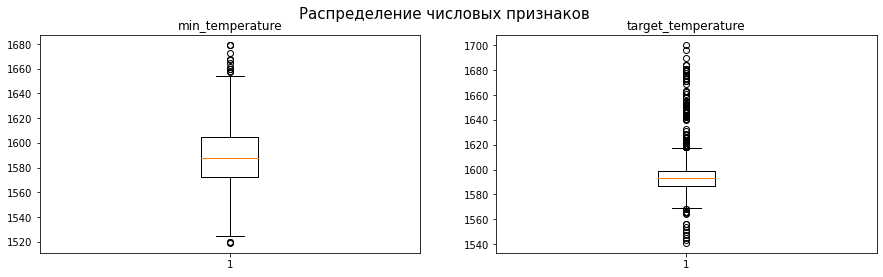

In [43]:
box_plot(data=df_temp, num_cols=df_temp.columns, n=2)

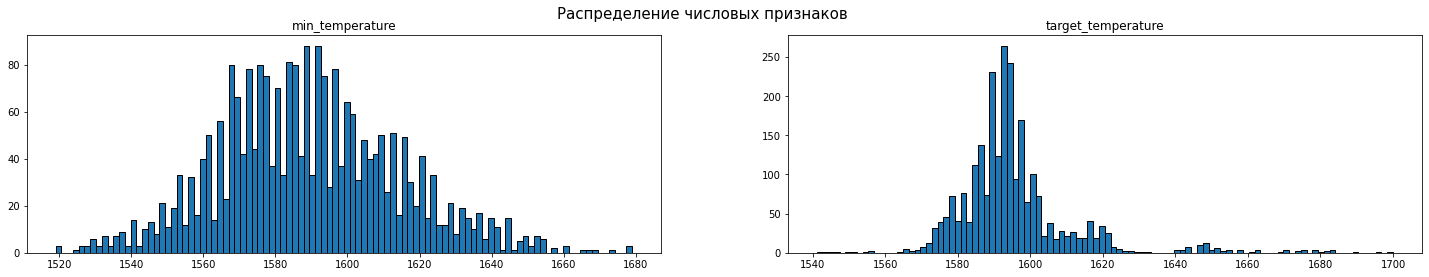

In [44]:
hist_plot(data=df_temp, num_cols=df_temp.columns, n=2)

Распределение температур похоже на нормальное. Т.к. заказчик прямо указал, что значения температуры ниже 1500 градусов — аномальные, то все остальные будем считать нормой, и сохраним значения, как есть.

In [45]:
df_temp.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2475 entries, 1 to 2499
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   min_temperature     2475 non-null   float64
 1   target_temperature  2475 non-null   float64
dtypes: float64(2)
memory usage: 58.0 KB


В результате получили 2475 строк и 2 столбца(один из которых - целевой признак) агрегированных данных.

### **Таблица `steel.data_wire`**

In [46]:
df_wire = read_sql('data_wire')
df_wire = df_wire.set_index('key')
df_wire.info()
df_wire.head(10)

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3081 entries, 1 to 3241
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Wire 1  3055 non-null   float64
 1   Wire 2  1079 non-null   float64
 2   Wire 3  63 non-null     float64
 3   Wire 4  14 non-null     float64
 4   Wire 5  1 non-null      float64
 5   Wire 6  73 non-null     float64
 6   Wire 7  11 non-null     float64
 7   Wire 8  19 non-null     float64
 8   Wire 9  29 non-null     float64
dtypes: float64(9)
memory usage: 240.7 KB


,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
key,,,,,,,,,
1,60.059998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,96.052315,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,91.160157,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,89.063515,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,89.238236,9.114560,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,99.109917,9.114560,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,98.061600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,155.282394,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,113.393279,9.143681,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [47]:
df_wire.columns = [column.lower().replace(' ', '_') for column in df_wire.columns]

В таблице большое количество пропусков, что свидетельствует о недобавлении данного проволочного материала. Можно заполнить данные пропуски нулями.

In [48]:
df_wire = df_wire.fillna(0)

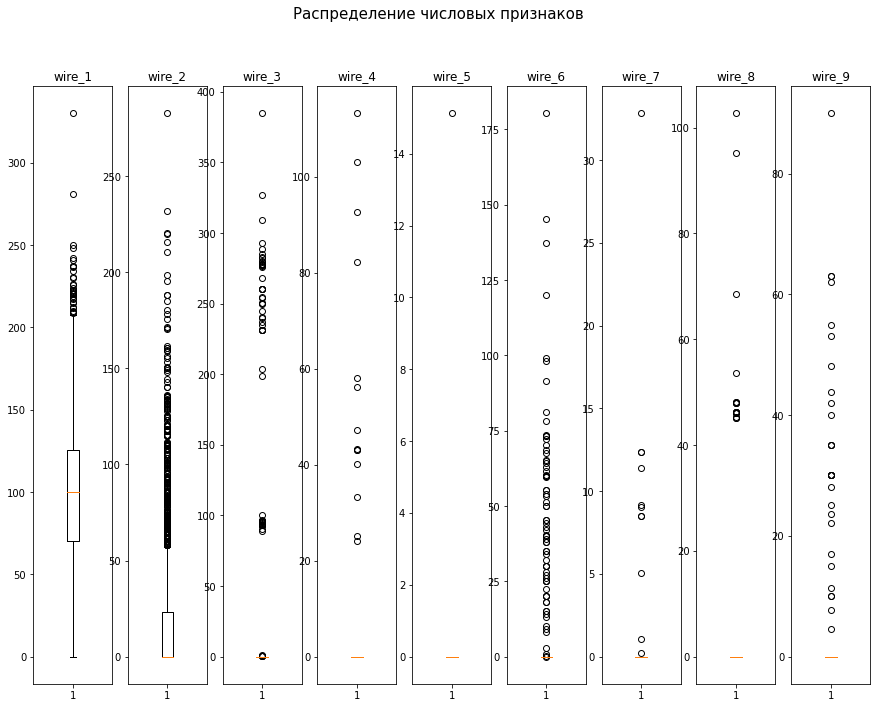

In [49]:
box_plot(data=df_wire, num_cols=df_wire.columns, n=5)

Большинство проволочных материалов редко добавляется в сплавы, поэтому их добавление выглядит, как выброс, такие данные сохраним.

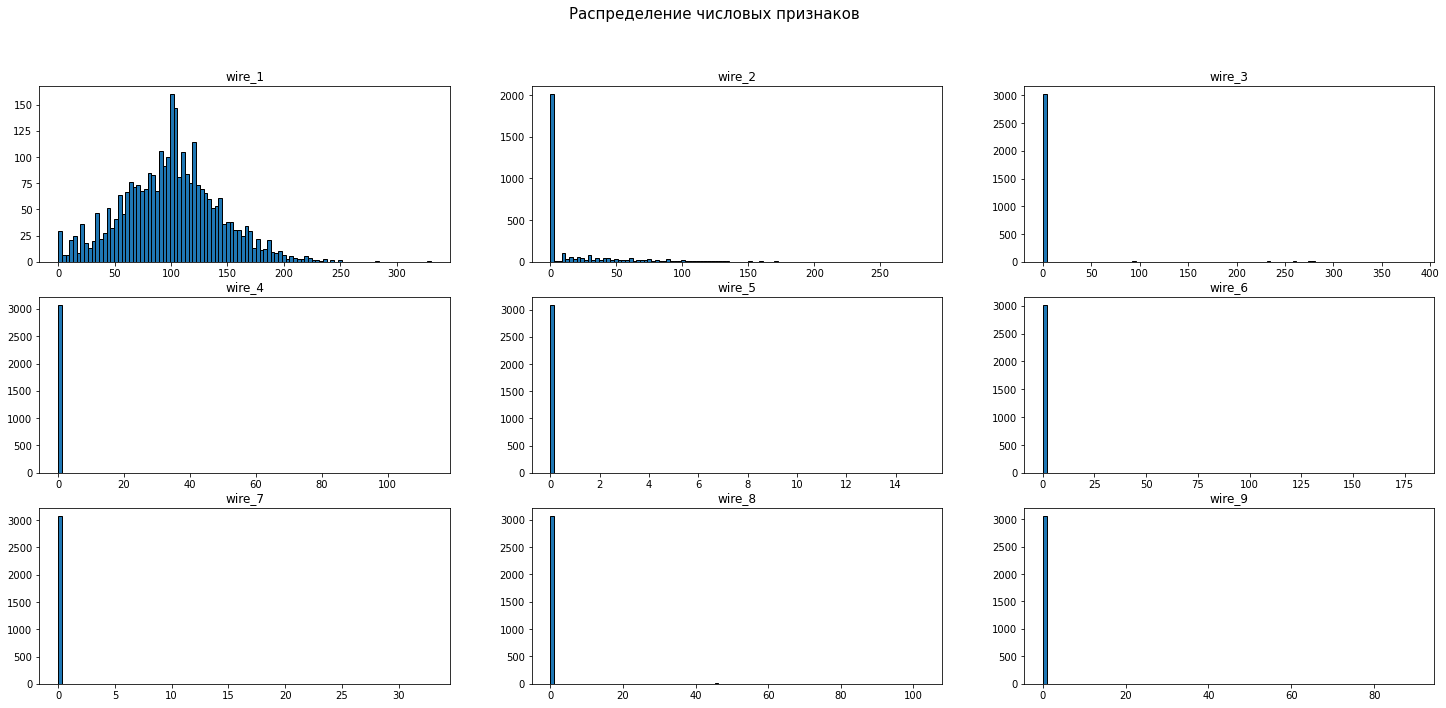

In [50]:
hist_plot(data=df_wire, num_cols=df_wire.columns, n=3)

Распределение добавления первого материала похоже на нормальное. Для всех остальных материалов в распределении явно преобладает 0.

In [51]:
df_wire.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3081 entries, 1 to 3241
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   wire_1  3081 non-null   float64
 1   wire_2  3081 non-null   float64
 2   wire_3  3081 non-null   float64
 3   wire_4  3081 non-null   float64
 4   wire_5  3081 non-null   float64
 5   wire_6  3081 non-null   float64
 6   wire_7  3081 non-null   float64
 7   wire_8  3081 non-null   float64
 8   wire_9  3081 non-null   float64
dtypes: float64(9)
memory usage: 240.7 KB


В результате получили 3059 строк и 9 столбцов обработанных данных.

### **Таблица `steel.data_wire_time`**

In [52]:
df_wire_time = read_sql('data_wire_time')
df_wire_time = df_wire_time.set_index('key')
df_wire_time.info()
df_wire_time.head(10)

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3081 entries, 1 to 3241
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Wire 1  3055 non-null   object
 1   Wire 2  1079 non-null   object
 2   Wire 3  63 non-null     object
 3   Wire 4  14 non-null     object
 4   Wire 5  1 non-null      object
 5   Wire 6  73 non-null     object
 6   Wire 7  11 non-null     object
 7   Wire 8  19 non-null     object
 8   Wire 9  29 non-null     object
dtypes: object(9)
memory usage: 240.7+ KB


,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
key,,,,,,,,,
1,11:11:41,None,None,None,None,None,None,None,None
2,11:46:10,None,None,None,None,None,None,None,None
3,12:13:47,None,None,None,None,None,None,None,None
4,12:48:05,None,None,None,None,None,None,None,None
5,13:18:15,13:32:06,None,None,None,None,None,None,None
6,13:59:02,13:59:54,None,None,None,None,None,None,None
7,14:28:46,None,None,None,None,None,None,None,None
8,15:03:42,None,None,None,None,None,None,None,None
9,15:42:43,15:58:12,None,None,None,None,None,None,None


Наличие данных в таблице со временем подачи соответствует наличию факта подачи в предыдущей таблице. Пропуски также можно заменить нулями.

In [53]:
df_wire_time.columns = df_wire.columns

In [54]:
df_wire_time = df_wire_time.fillna(0)

**Вывод по второму шагу:** после проведенного исследовательского анализа данных для каждой таблицы можно сделать следующие выводы:
* обработали таблицу с данными об электродах, избавились от аномалий, на основе этих данных создали новые признаки:
продолжительность нагрева, количество запусков нагрева электродами, полную мощность, потребление электроэнергии. Определили, что все признаки данной таблицы имеют гамма-распределение.
* в таблице с тобавлением сыпучих материалов было много пропусков, что свидетельствует о недобавлении данного материала, поэтому заполнили их нулями. Как итог и распределение сыпучих материалов в основном тяготеет к нулю.
* в таблице со временем добавления убедились, что факт и время добавления сыпучих материалов совпадают.
* заполнили пропуски в таблице с добавлением газа нулями, т.к. пропуски свидетельствуют о том, что газ не добавлялся. Добавление газа имеет гамма-распределение.
* удалили значения менее 1500 в таблице с температурой по рекомендации заказчика, обработали данные, оставив первый замер как признак и последний замер - как целевое значение, убрав остальные значение, чтобы избежать утечки признаков. Также устранили строки, где был выполнен только один замер. Определили, что температура распределена нормально.
* в таблице с тобавлением проволочных материалов было много пропусков, что свидетельствует о недобавлении данного материала, поэтому заполнили их нулями. Как итог и распределение проволочных материалов в основном тяготеет к нулю.
* в таблице со временем добавления убедились, что факт и время добавления проволочных материалов совпадают.

## 3. Объединение таблиц

In [55]:
df_names = [df_bulk, df_gas, df_temp, df_wire]
df = df_arc
for data in df_names:
    df = df.merge(data, on=['key'], how='inner')

In [56]:
df.info()
df.head(10)

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2329 entries, 1 to 2499
Data columns (total 33 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   heat_count          2329 non-null   int64  
 1   active_power        2329 non-null   float64
 2   reactive_power      2329 non-null   float64
 3   full_power          2329 non-null   float64
 4   heat_duration       2329 non-null   float64
 5   consumption         2329 non-null   float64
 6   bulk_1              2329 non-null   float64
 7   bulk_2              2329 non-null   float64
 8   bulk_3              2329 non-null   float64
 9   bulk_4              2329 non-null   float64
 10  bulk_5              2329 non-null   float64
 11  bulk_6              2329 non-null   float64
 12  bulk_7              2329 non-null   float64
 13  bulk_8              2329 non-null   float64
 14  bulk_9              2329 non-null   float64
 15  bulk_10             2329 non-null   float64
 16  bulk_1

,heat_count,active_power,reactive_power,full_power,heat_duration,consumption,bulk_1,bulk_2,bulk_3,bulk_4,...,target_temperature,wire_1,wire_2,wire_3,wire_4,wire_5,wire_6,wire_7,wire_8,wire_9
key,,,,,,,,,,,,,,,,,,,,,
1,5,4.878147,3.183241,5.826395,1098.0,1442.377754,0.0,0.0,0.0,43.0,...,1613.0,60.059998,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,4,3.052598,1.998112,3.649216,811.0,881.233565,0.0,0.0,0.0,73.0,...,1602.0,96.052315,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,5,2.525882,1.599076,2.989534,655.0,525.066777,0.0,0.0,0.0,34.0,...,1599.0,91.160157,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,4,3.209250,2.060298,3.814962,741.0,796.911309,0.0,0.0,0.0,81.0,...,1625.0,89.063515,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,4,3.347173,2.252643,4.035758,869.0,1199.137958,0.0,0.0,0.0,78.0,...,1602.0,89.238236,9.114560,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,4,3.955108,2.689175,4.786837,952.0,1410.747219,0.0,0.0,0.0,117.0,...,1596.0,99.109917,9.114560,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,4,2.547375,1.561295,2.987777,673.0,729.780631,0.0,0.0,0.0,117.0,...,1599.0,98.061600,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,4,3.762755,2.680698,4.627389,913.0,1550.542227,0.0,0.0,0.0,99.0,...,1598.0,155.282394,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,5,2.081951,1.478671,2.555348,625.0,406.460647,0.0,0.0,0.0,117.0,...,1592.0,113.393279,9.143681,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Т.к. во все партии точно добавлялись сыпучие и проволочные материалы, везде была выполнена продувка газом и сплав всегда нагревался, выполним проверку добавления сыпучих и проволочных материалов. Продувку газом и нагрев мы обработали в прошлых шагах.

In [57]:
def empty_mask(row):
    sum_bulk = 0
    sum_wire = 0
    for column_bulk in df_bulk.columns:
        sum_bulk += row[column_bulk]
    for column_wire in df_wire.columns:
        sum_wire += row[column_wire]
    if (sum_bulk == 0) or ((sum_wire == 0)):
        row['mask'] = 1
    else:
        row['mask'] = 0
    return row

In [58]:
df = df.apply(empty_mask, axis=1)

In [59]:
df['mask'].value_counts()

0.0    2329
Name: mask, dtype: int64

Убедились, что во все партии точно добавлялись сыпучие и проволочные материалы. Уберем вспомогательный столбец.

In [60]:
df = df.drop('mask', axis=1)

In [61]:
(len(df_wire_time) - len(df)) / len(df_wire_time) * 100

24.407659850697826

Обработанный и окончательный датафрейм уменьшился по сравнению с первоначальным на 24,41%. Потеряли ощутимое количество данных, но получившийся набор должен с большим качеством обучить модель.

Визуализируем распределение каждого получившегося признака.

                                             |                                             | [  0%]   00:00 ->…


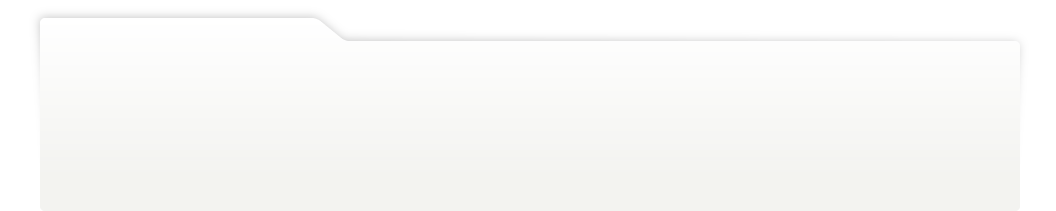
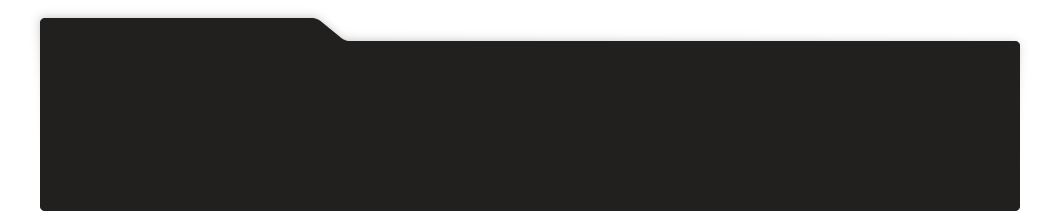
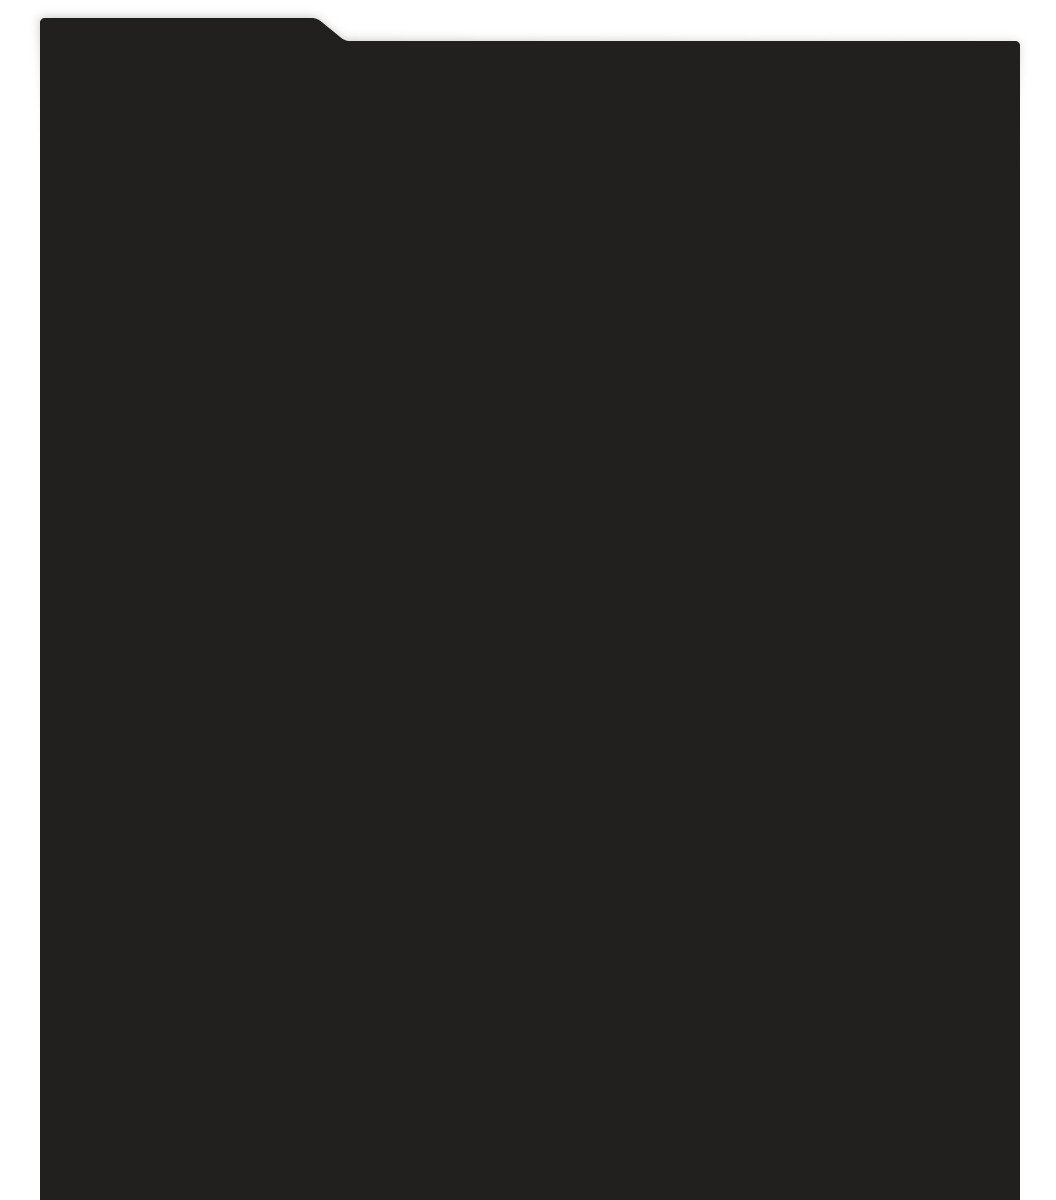
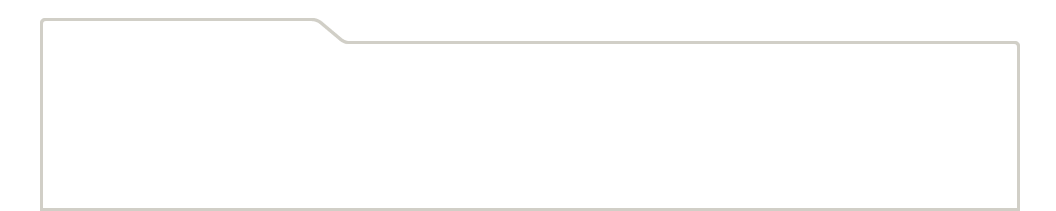
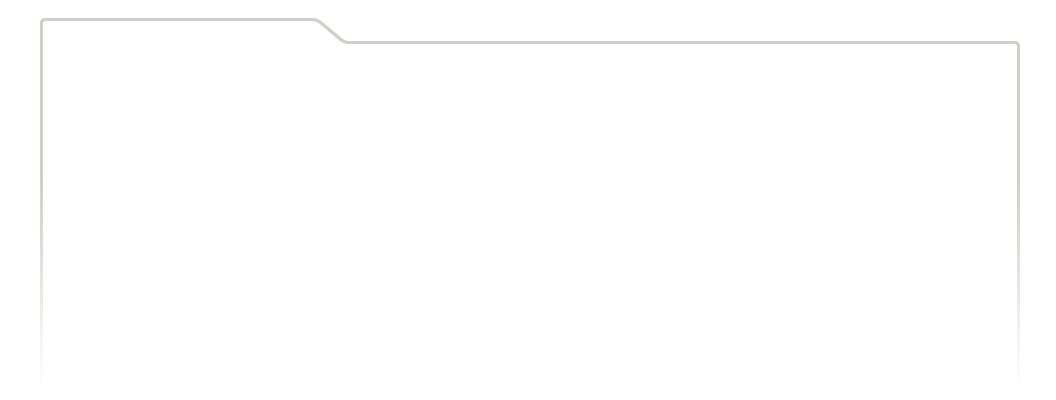
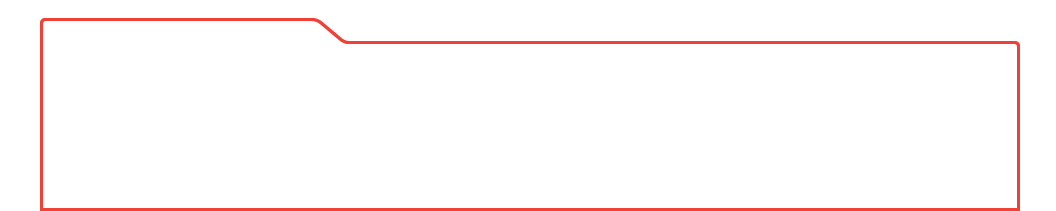
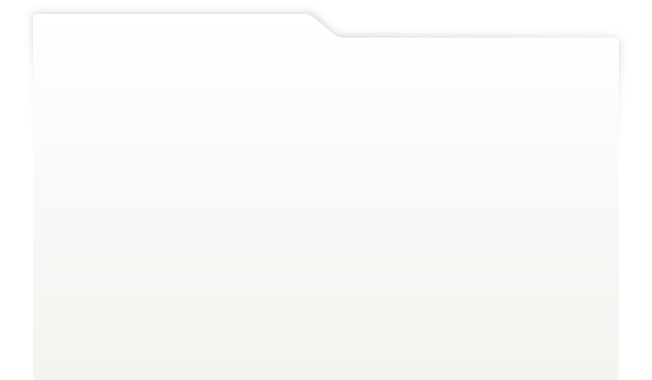
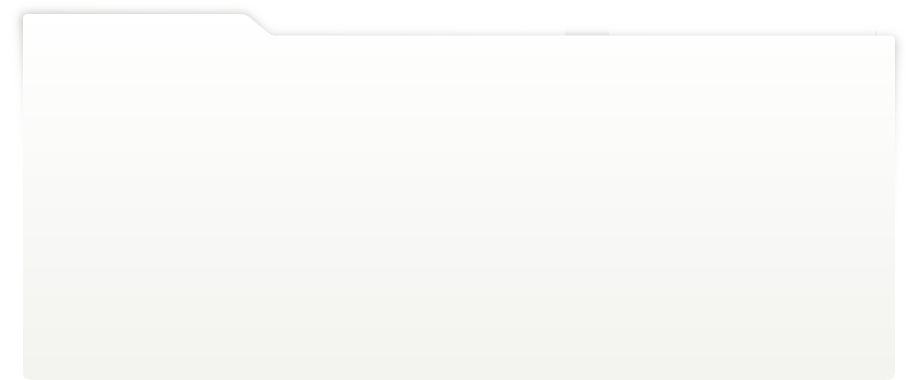
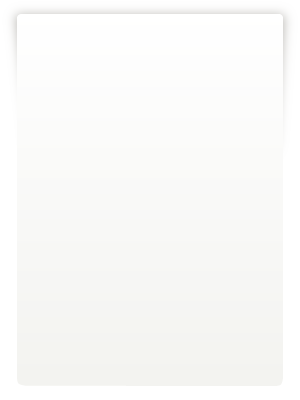
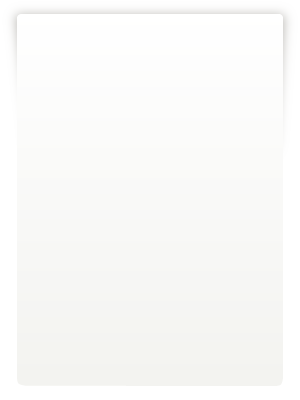
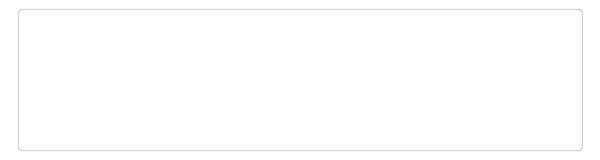
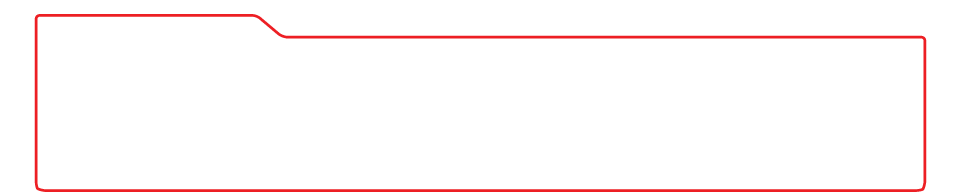
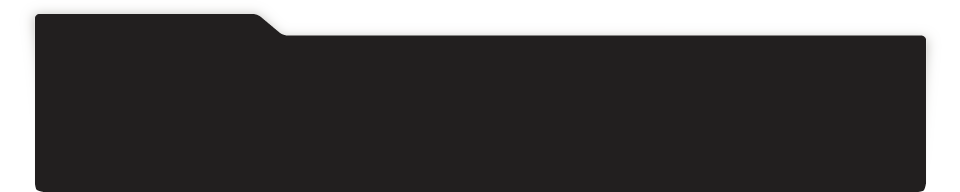
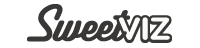
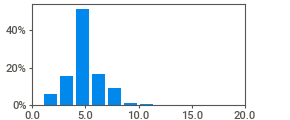
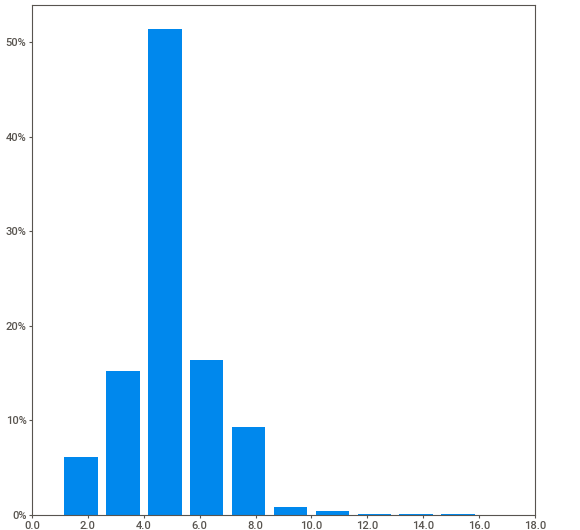
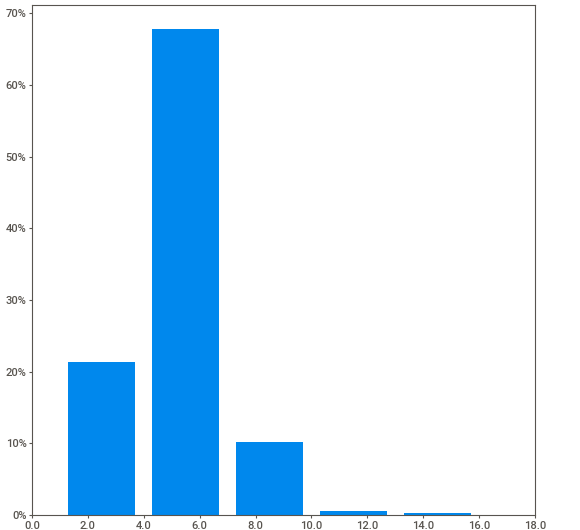
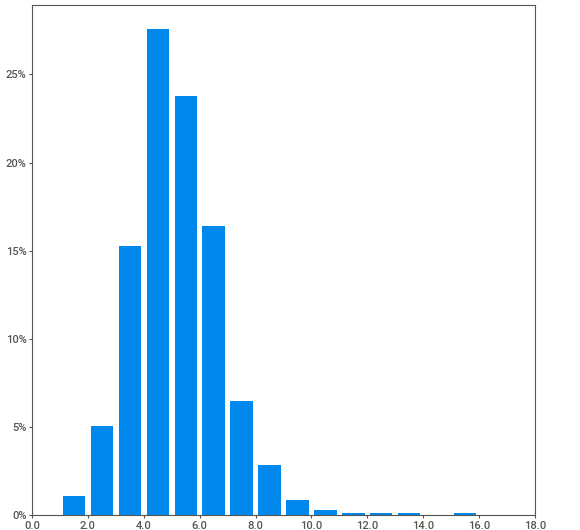
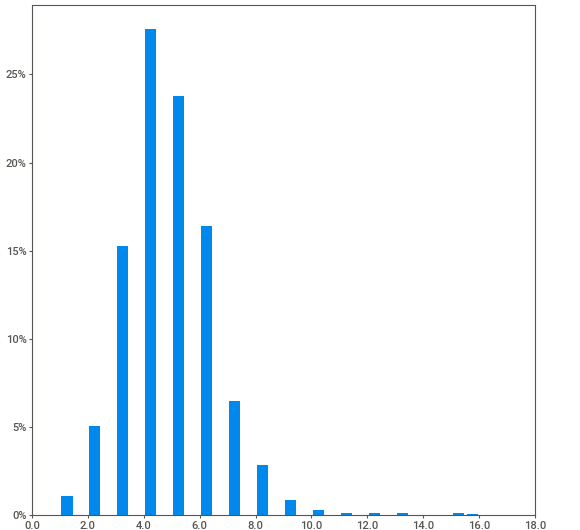
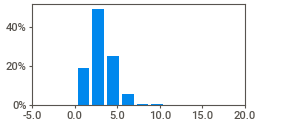
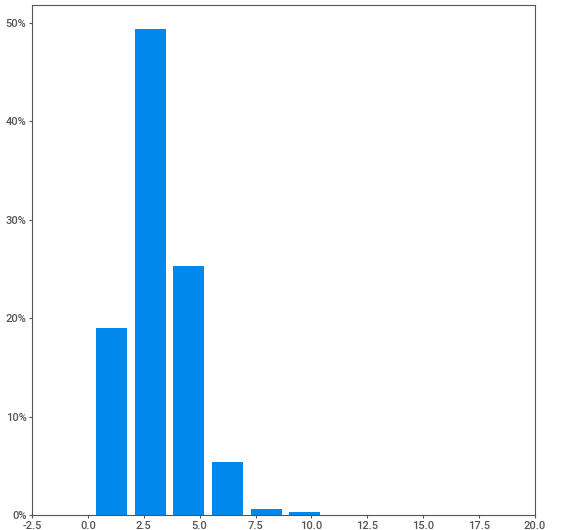
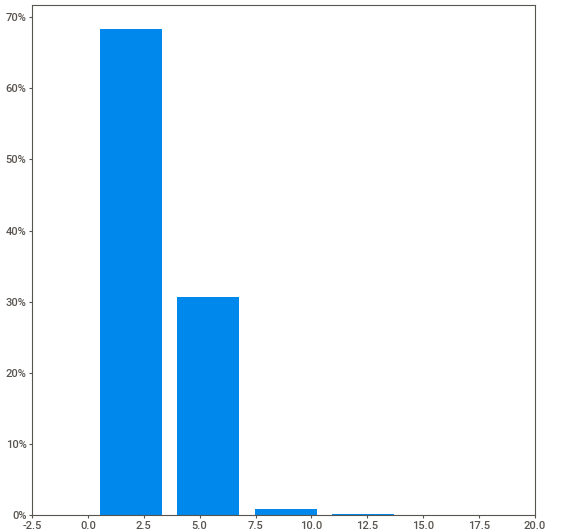
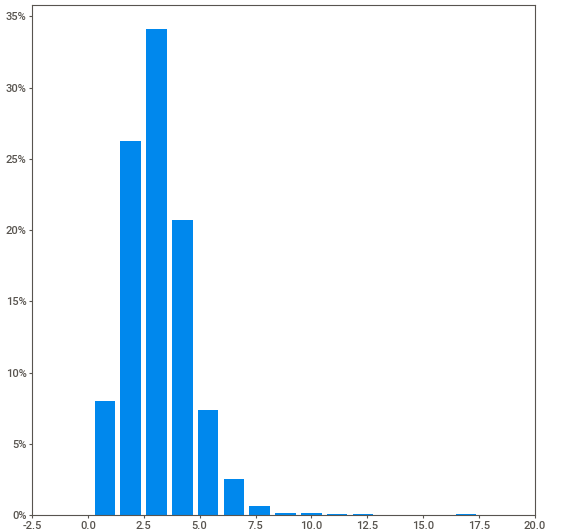
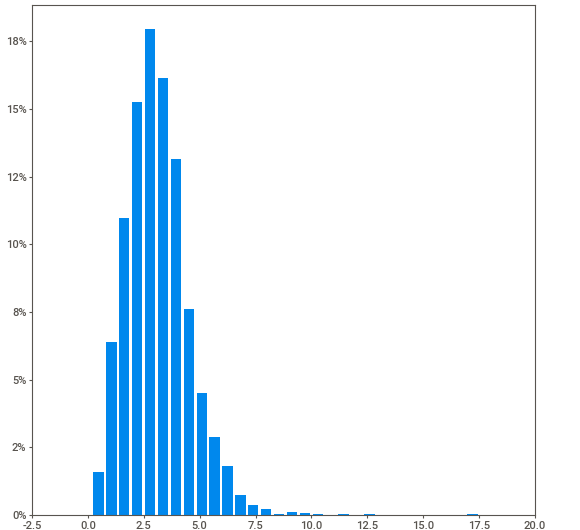
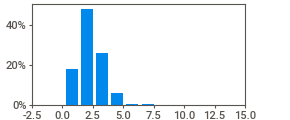
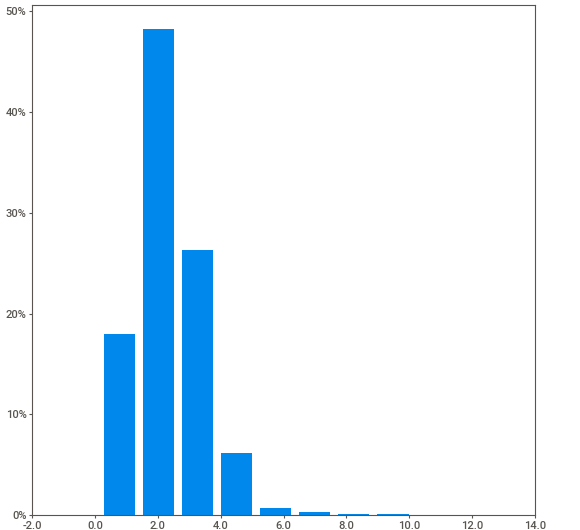
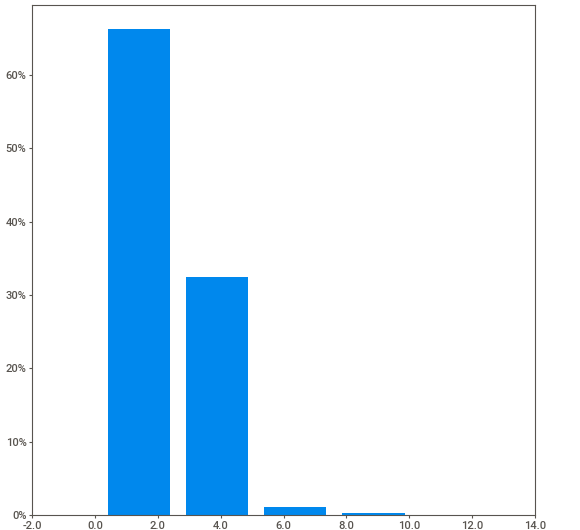
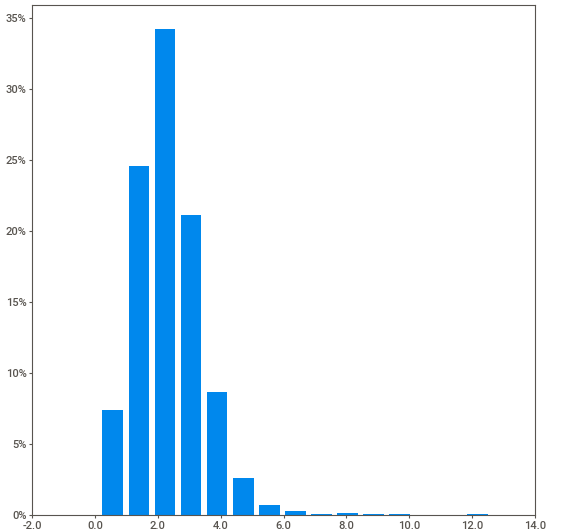
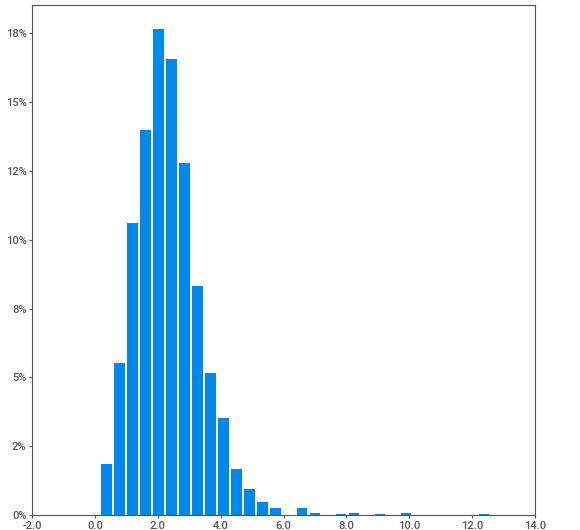
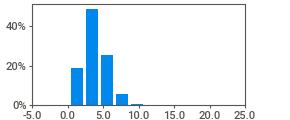
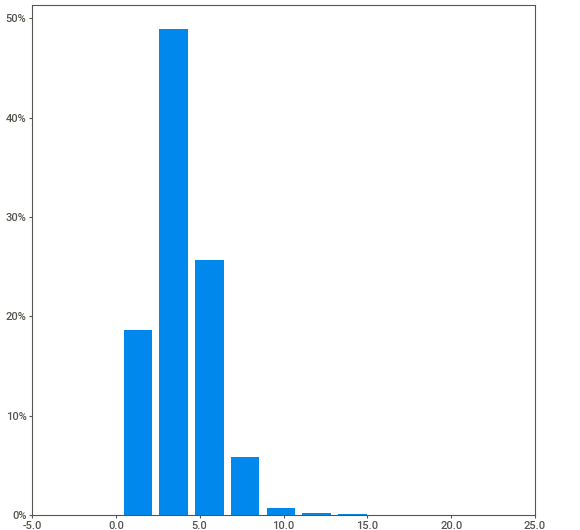
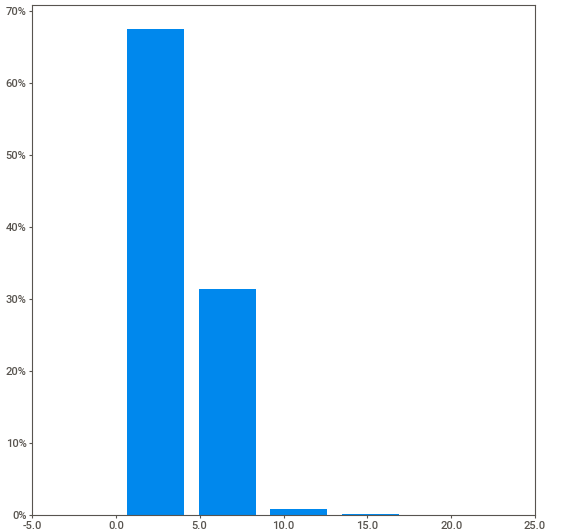
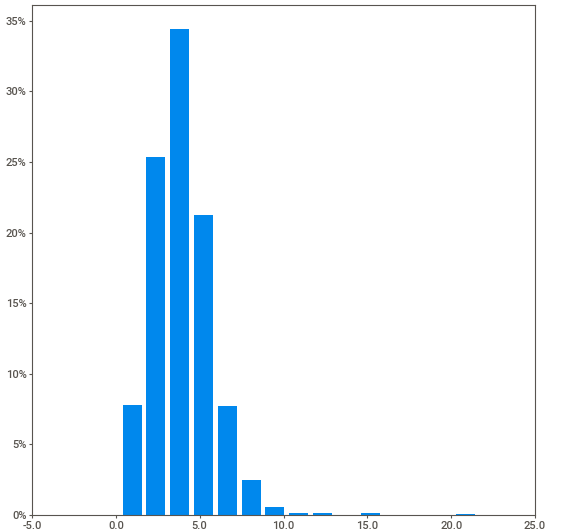
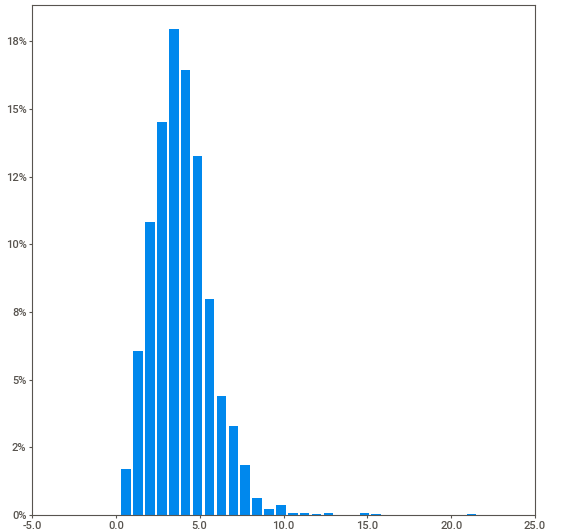
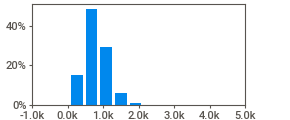
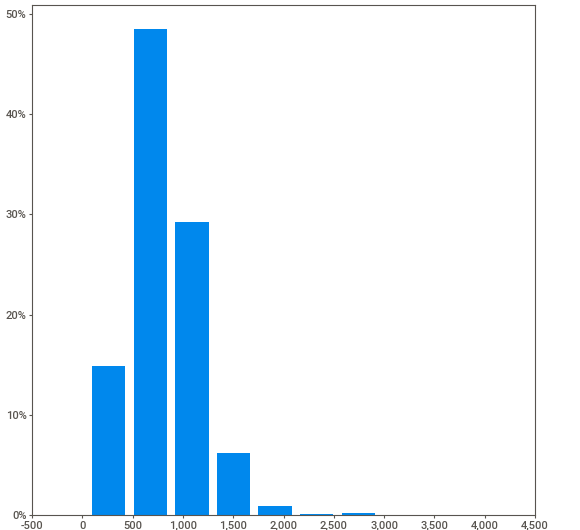
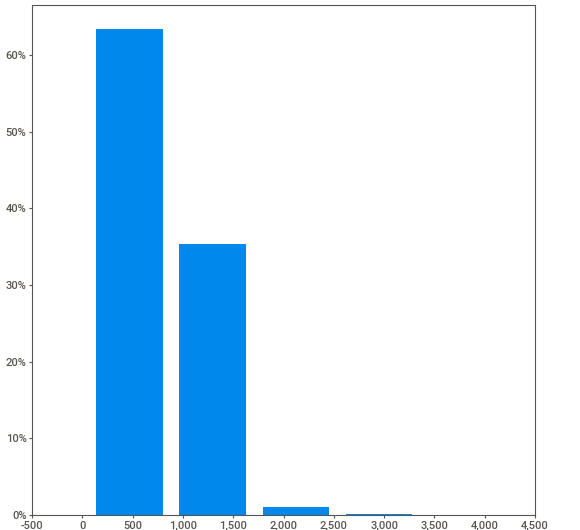
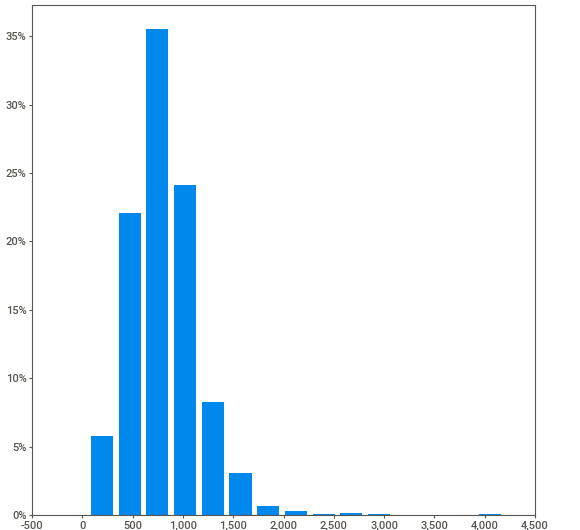
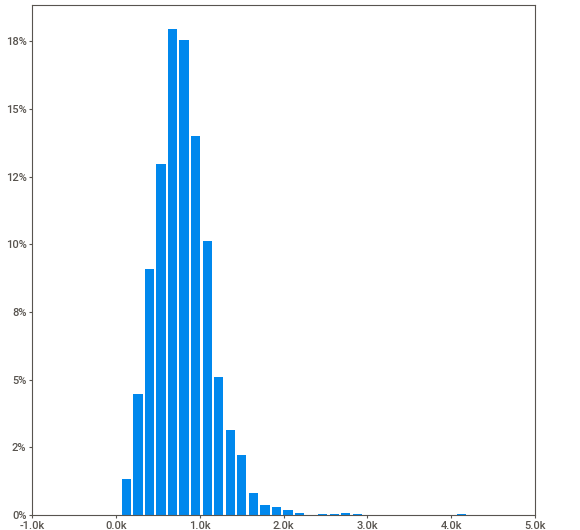
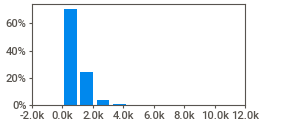
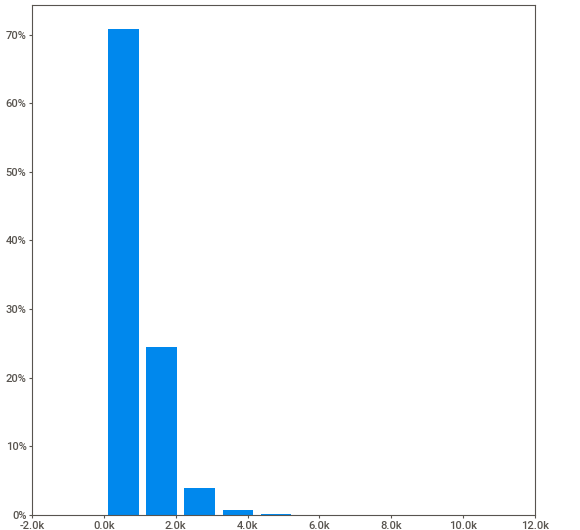
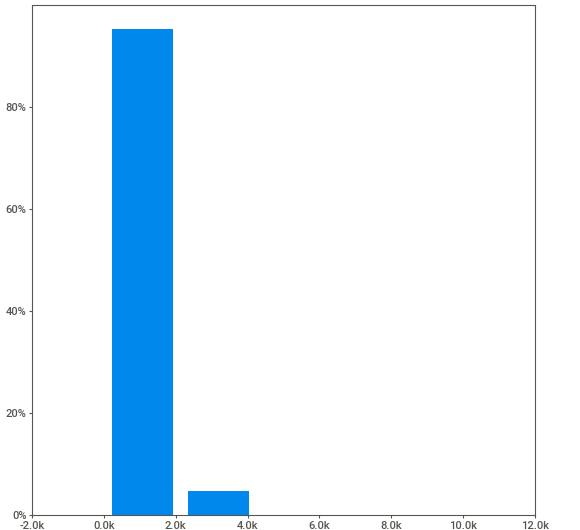
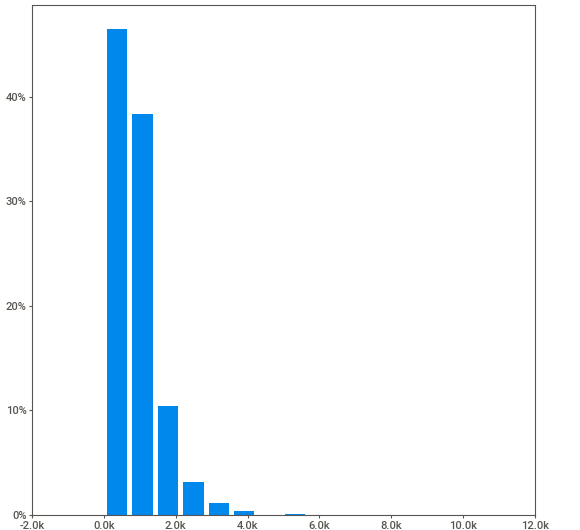
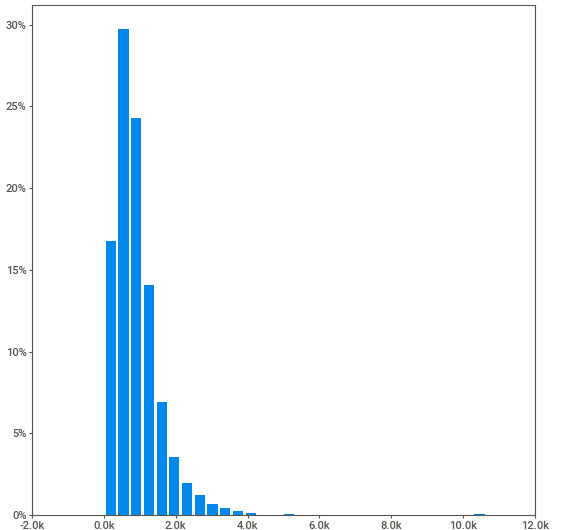
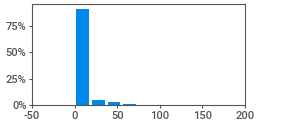
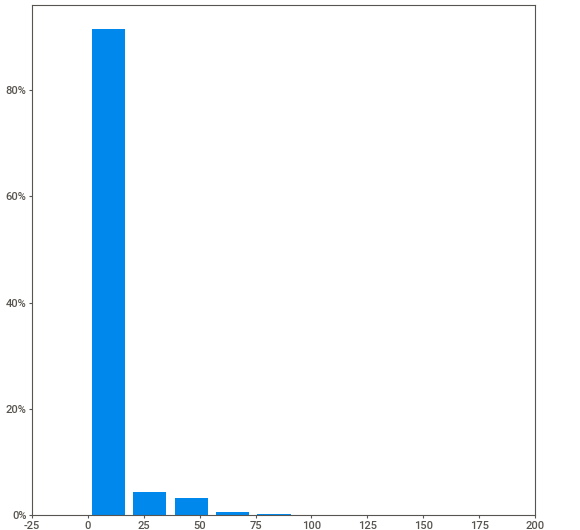
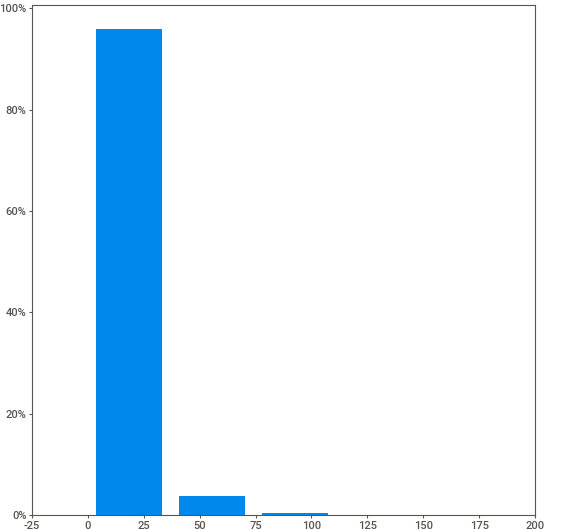
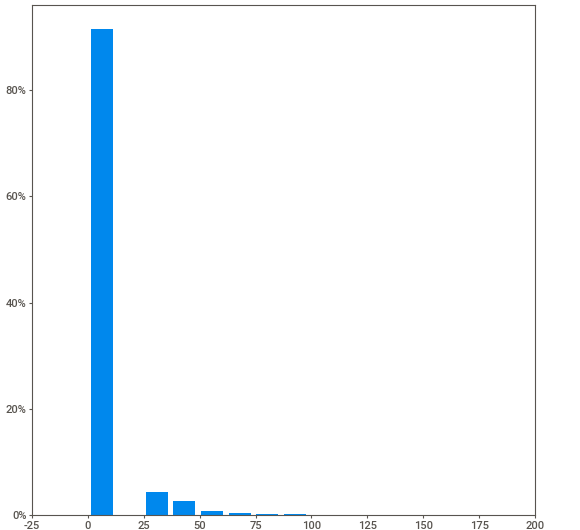
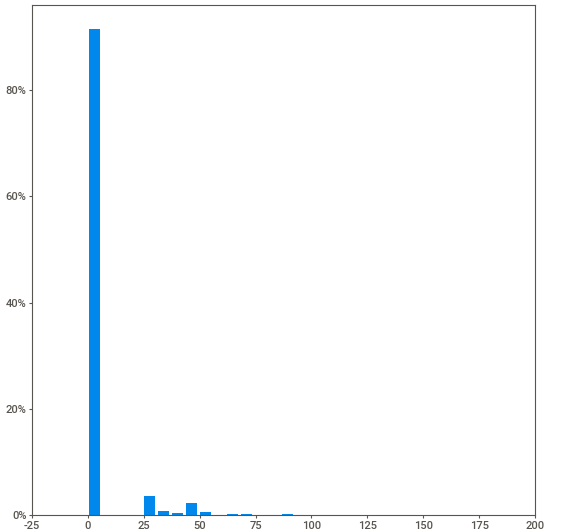
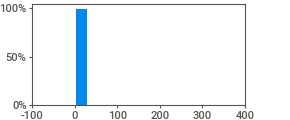
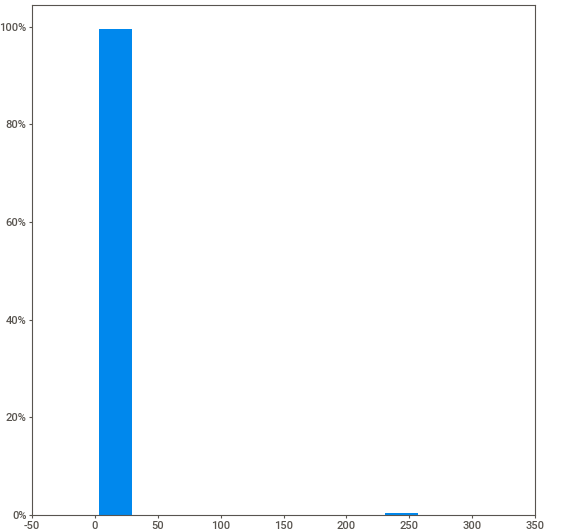
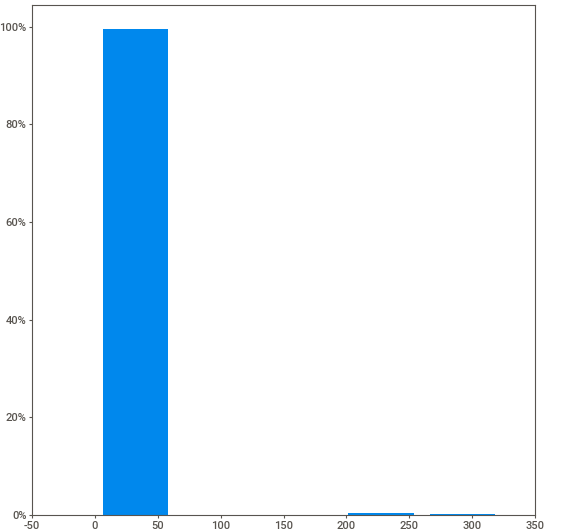
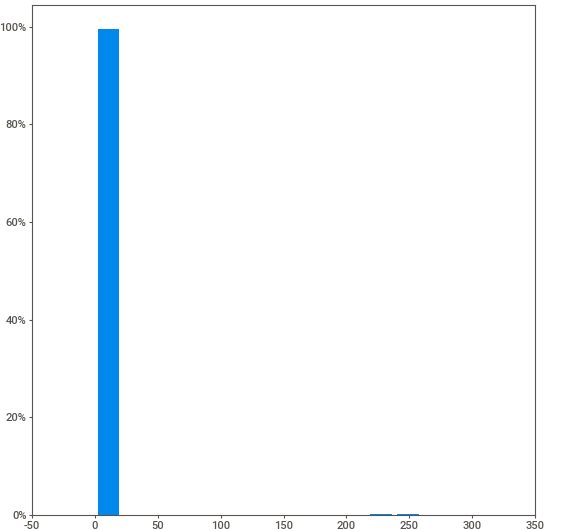
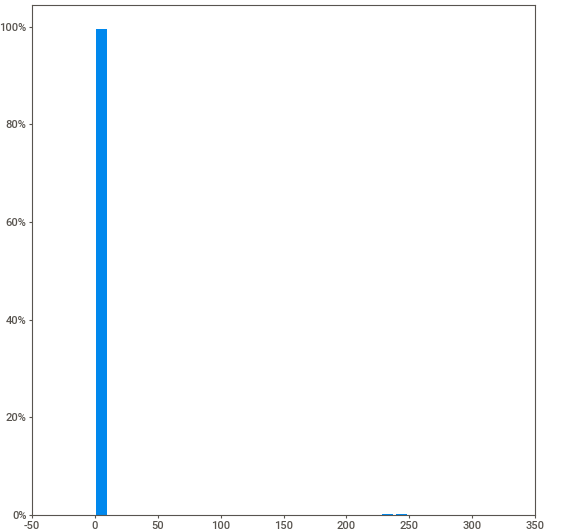
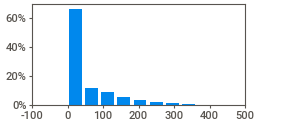
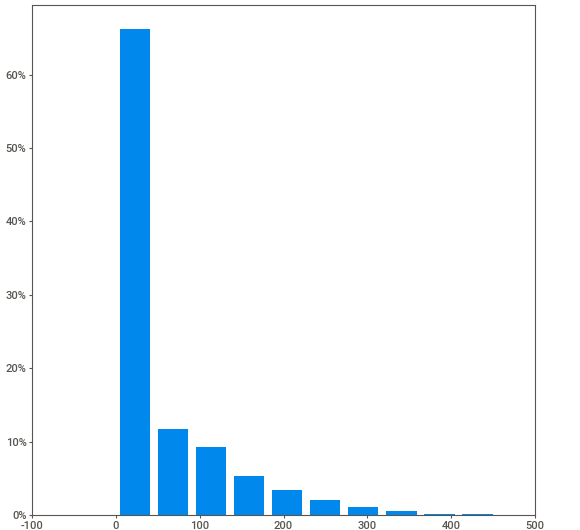
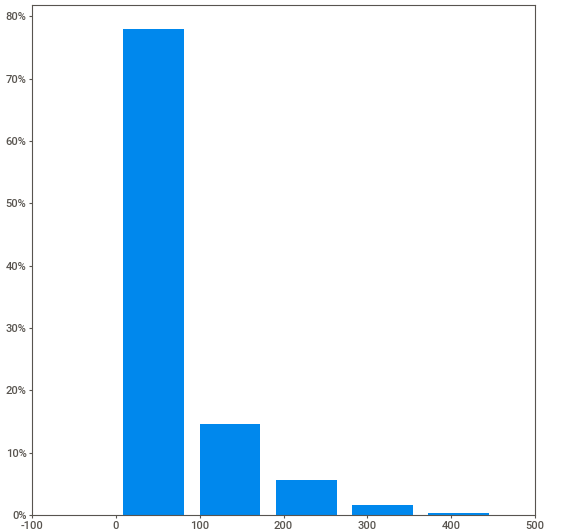
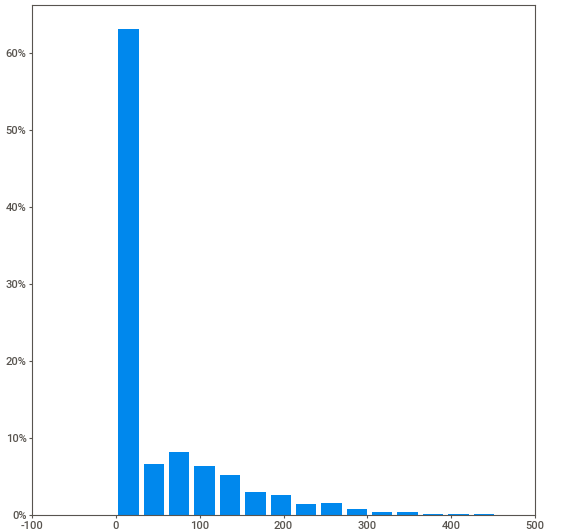
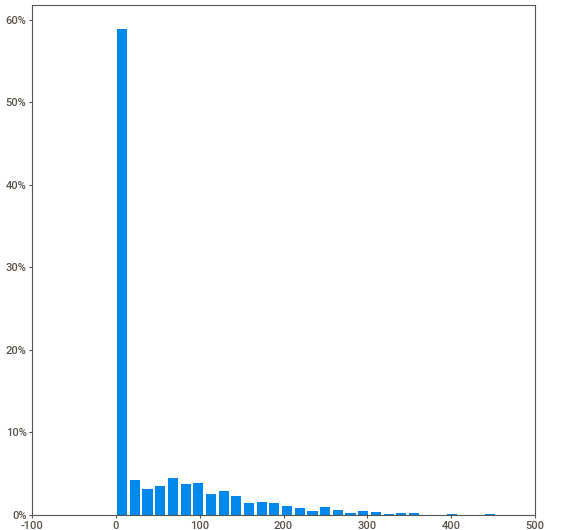
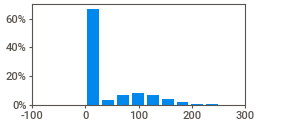
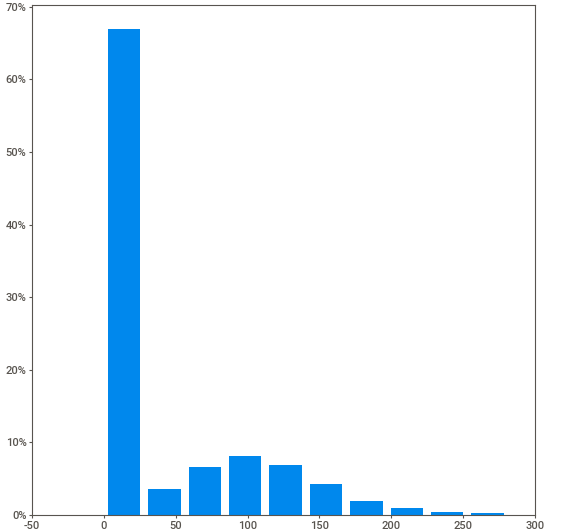
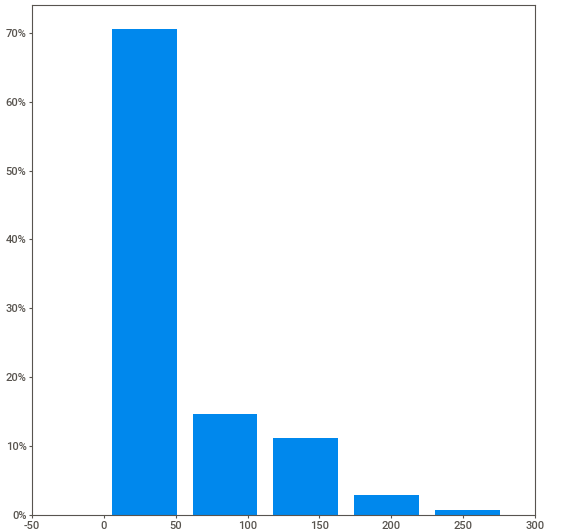
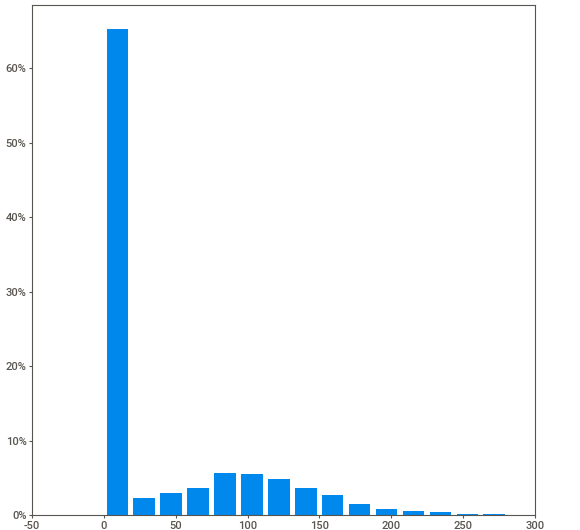
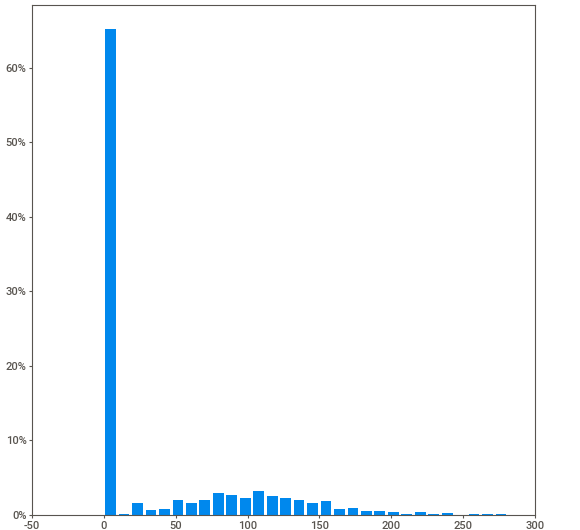
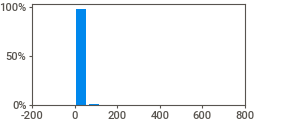
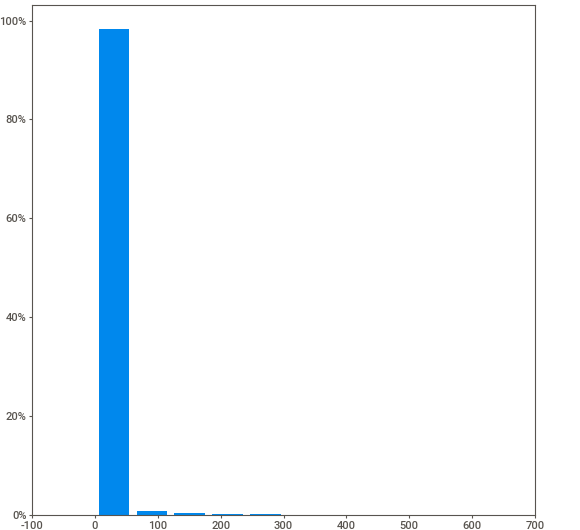
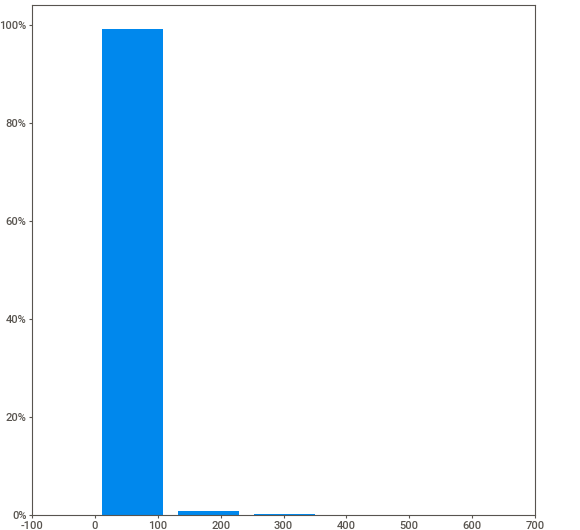
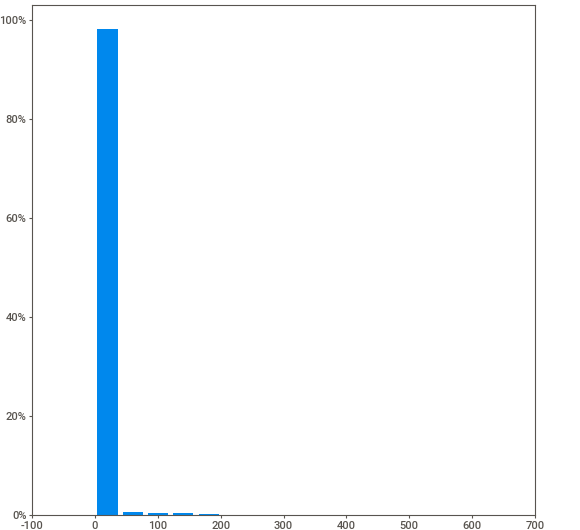
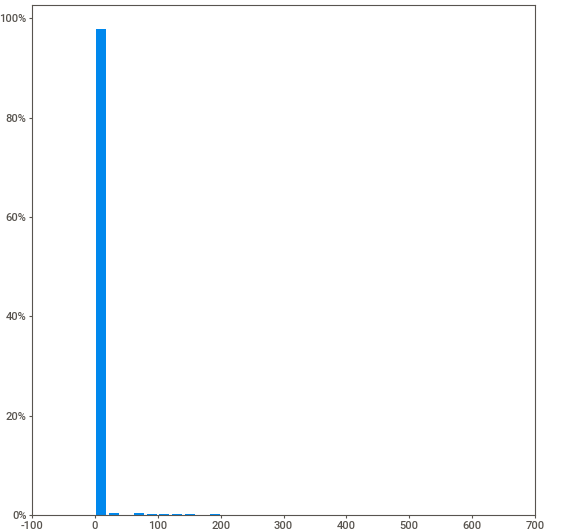
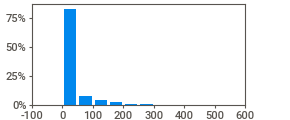
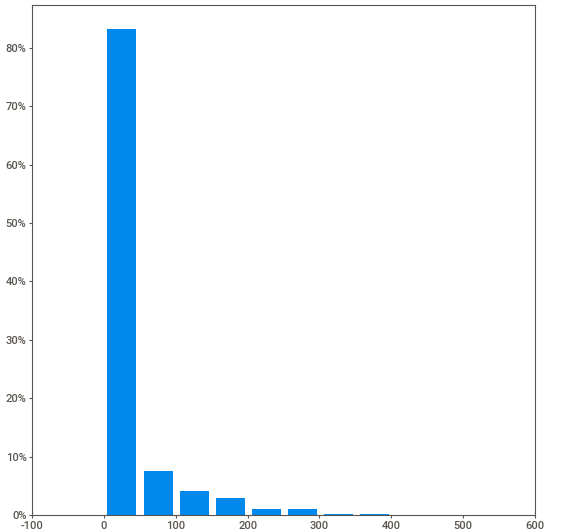
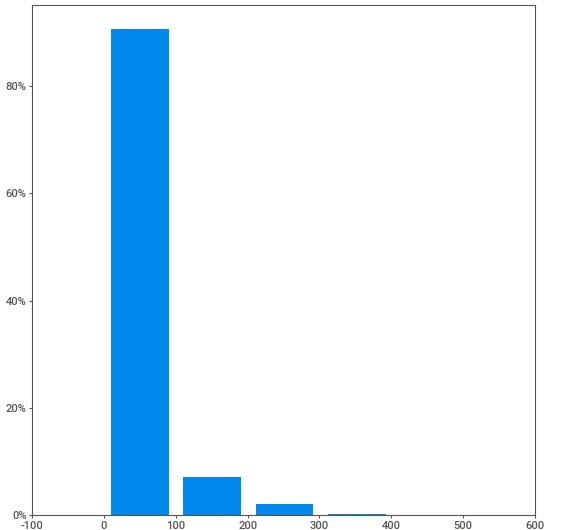
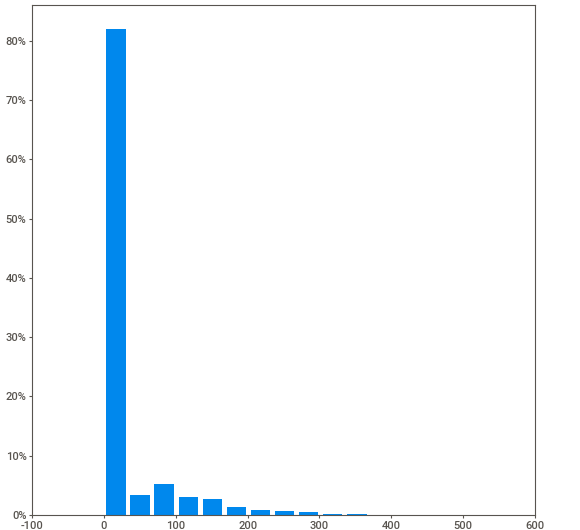
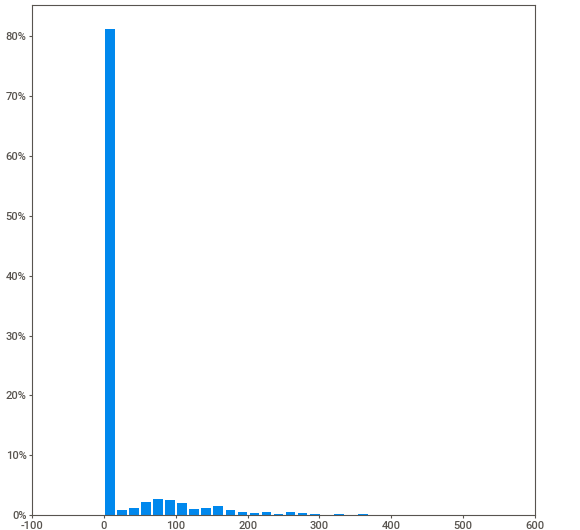
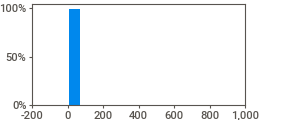
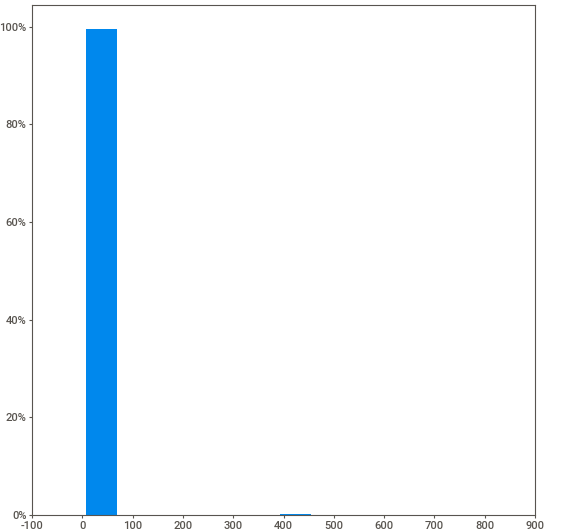
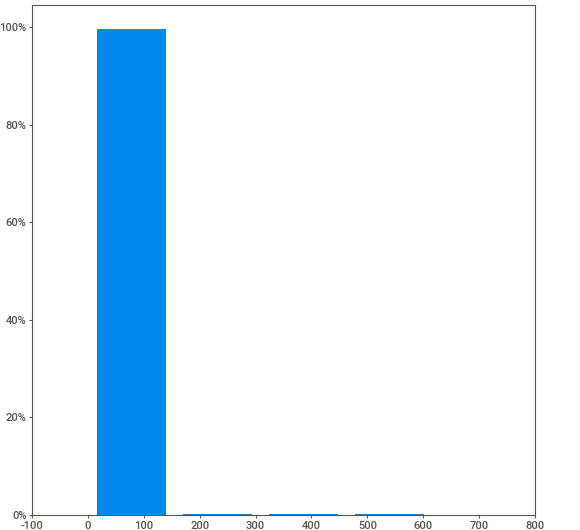
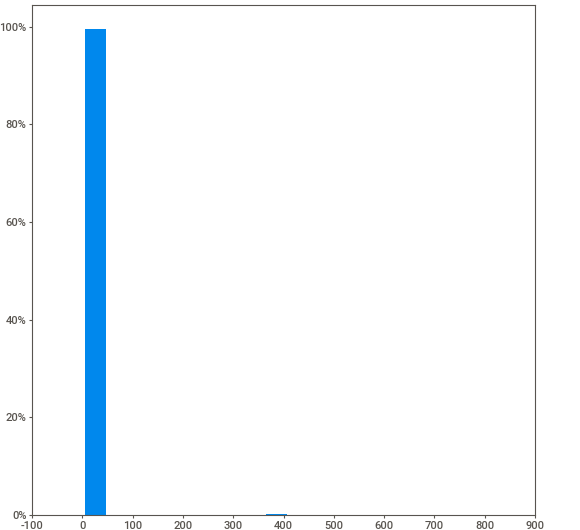
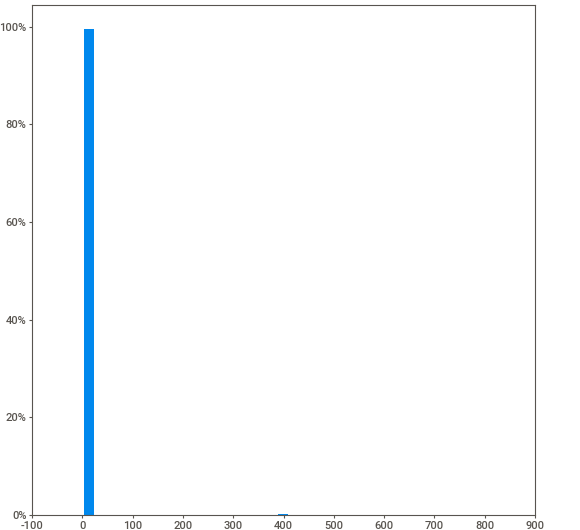
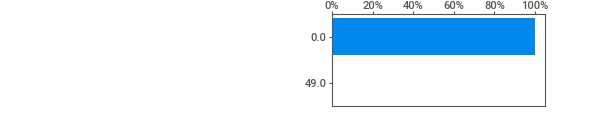
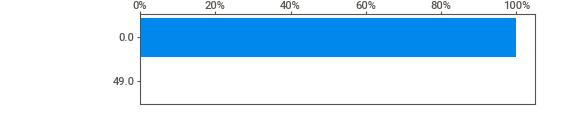
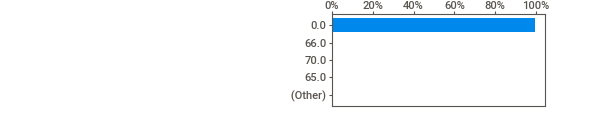
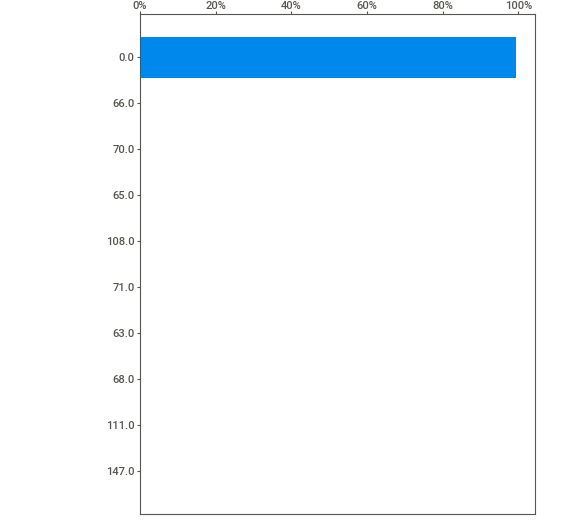
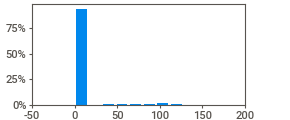
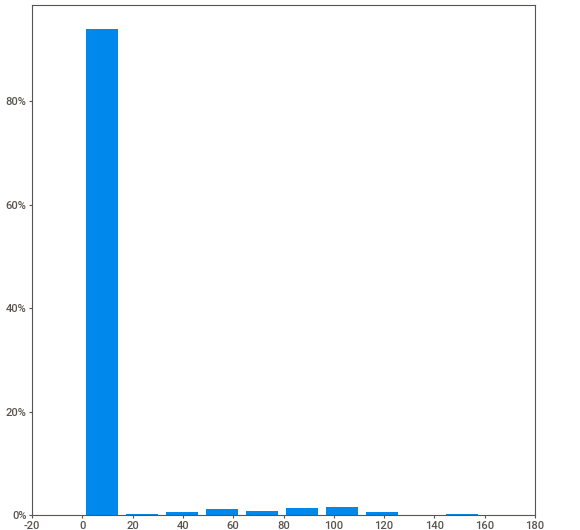
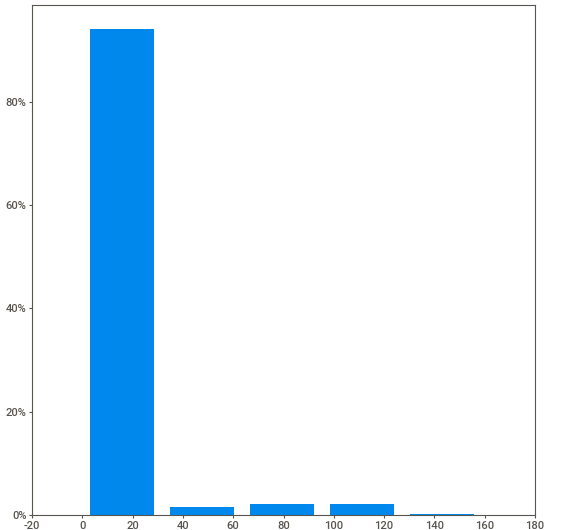
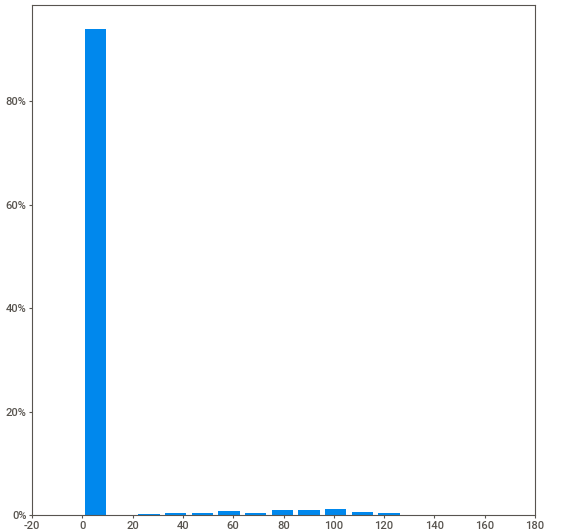
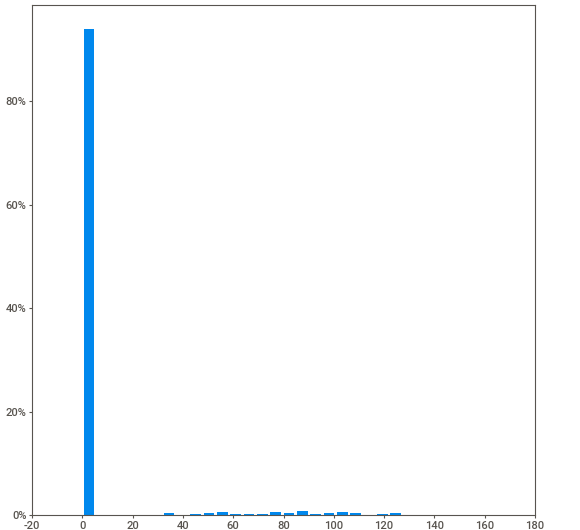
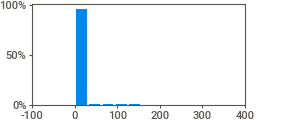
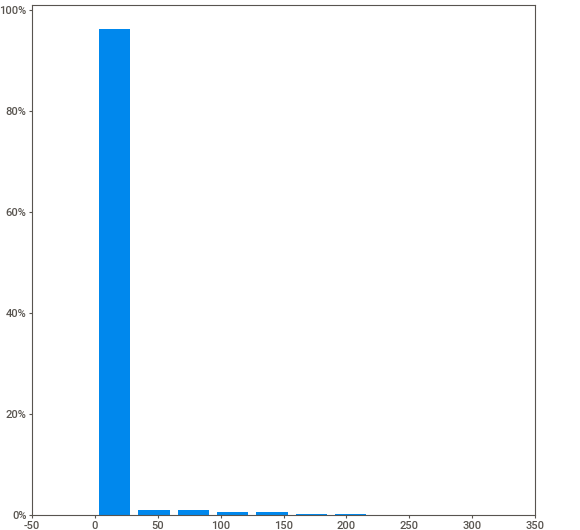
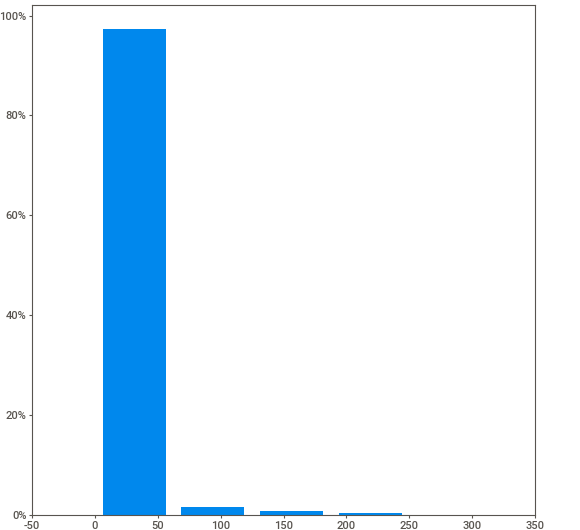
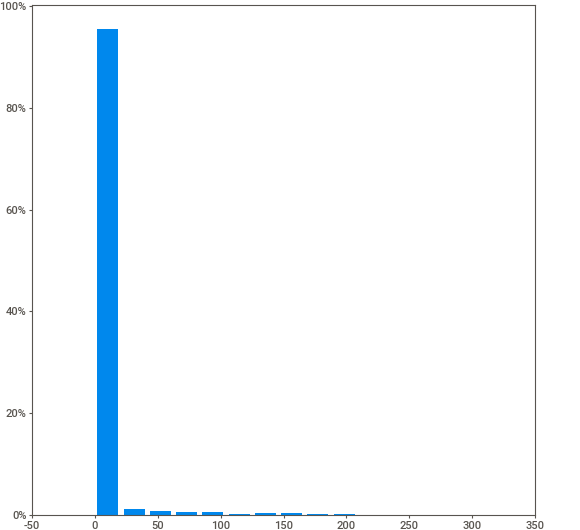
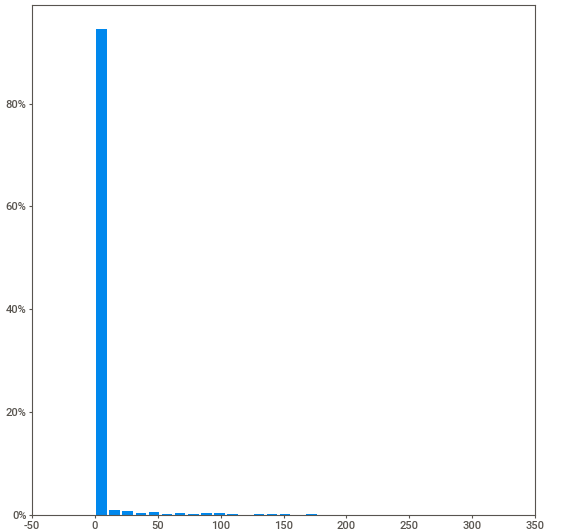
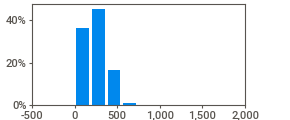
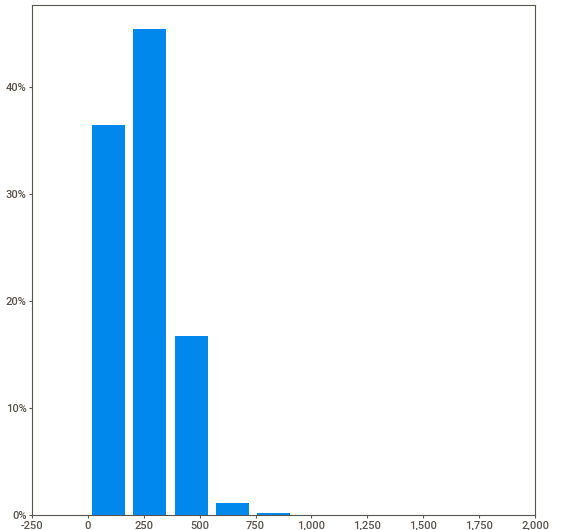
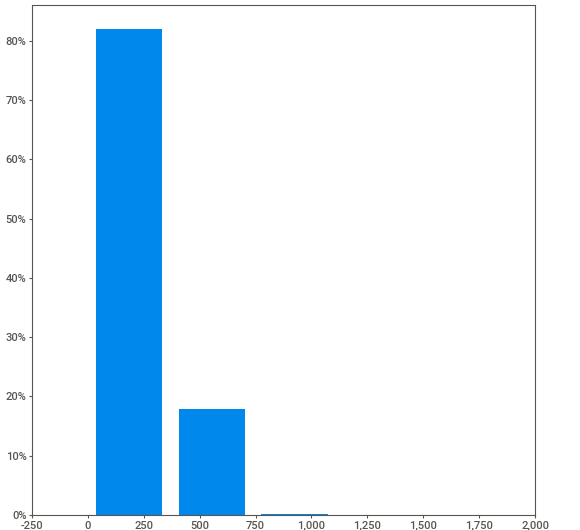
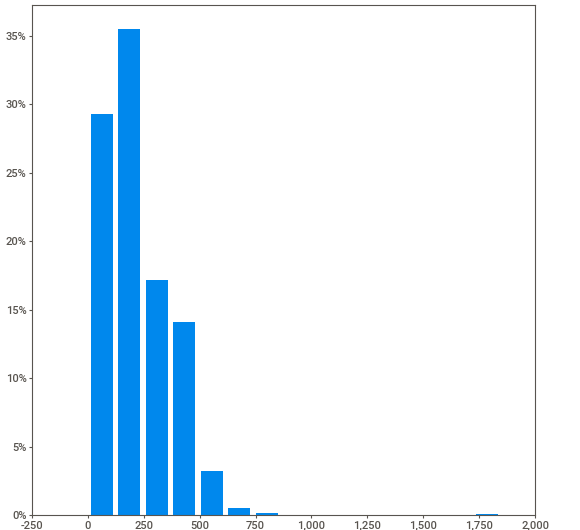
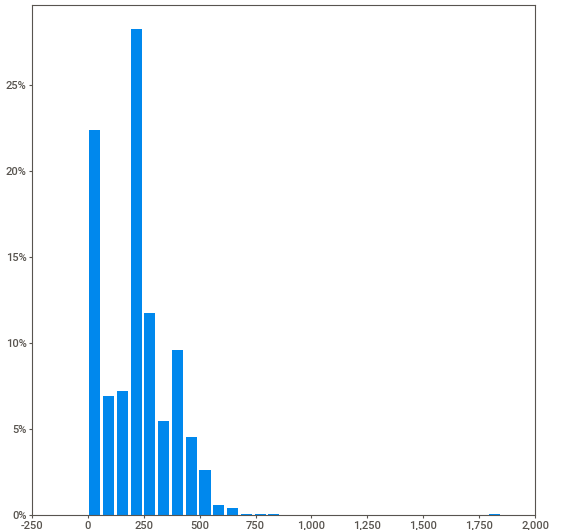
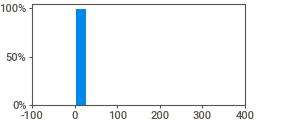
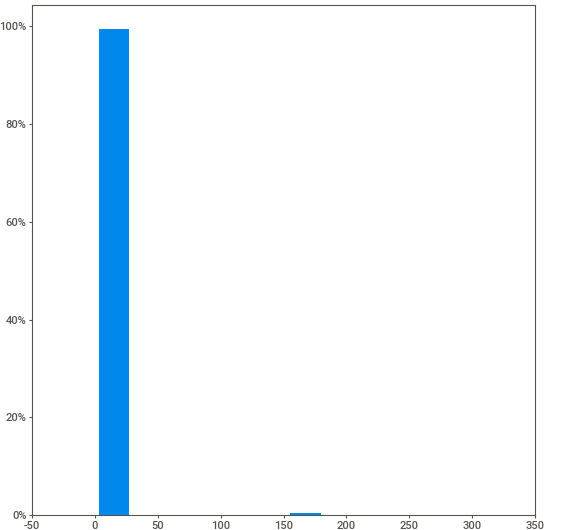
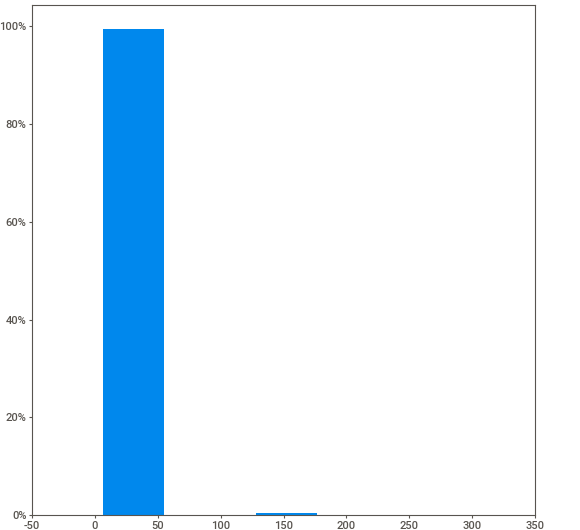
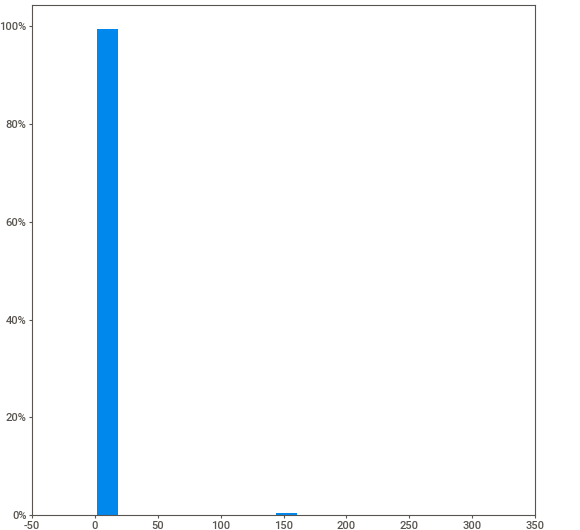
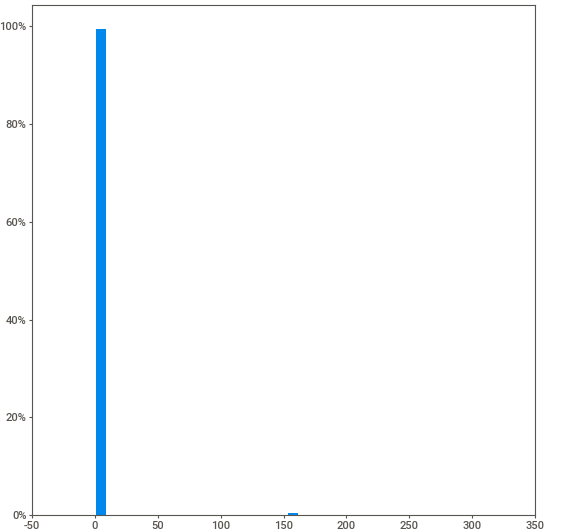
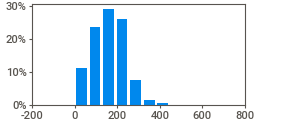
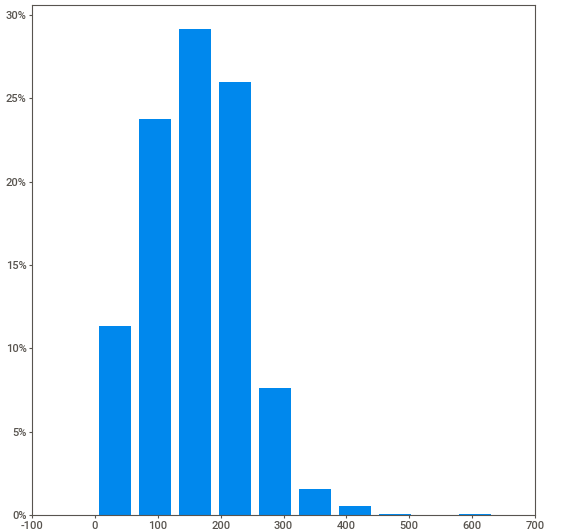
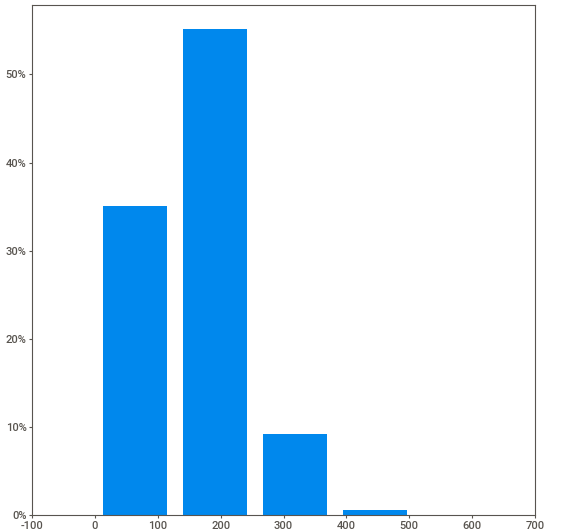
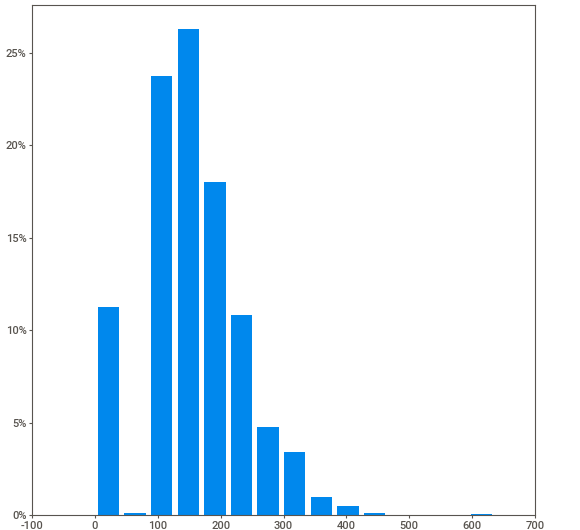
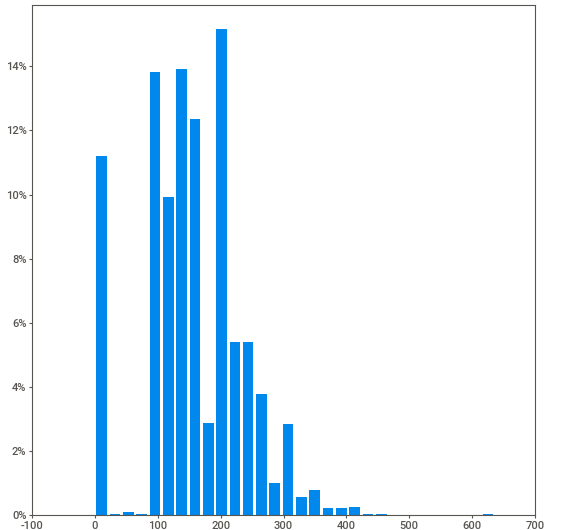
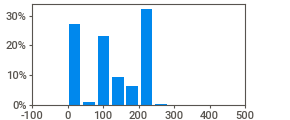
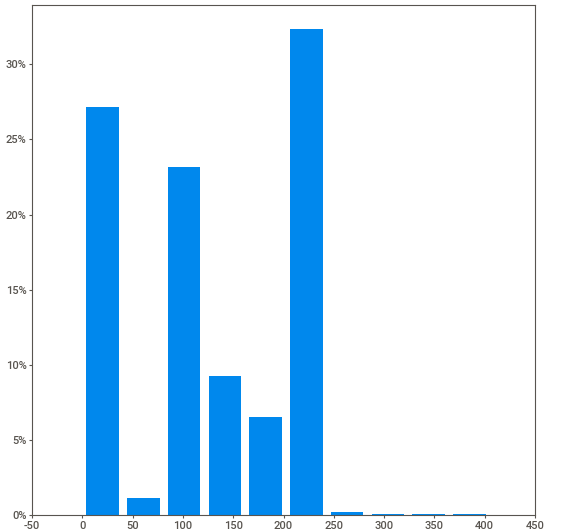
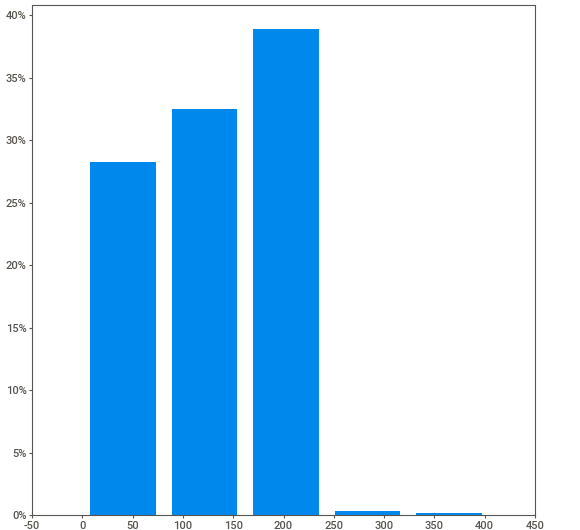
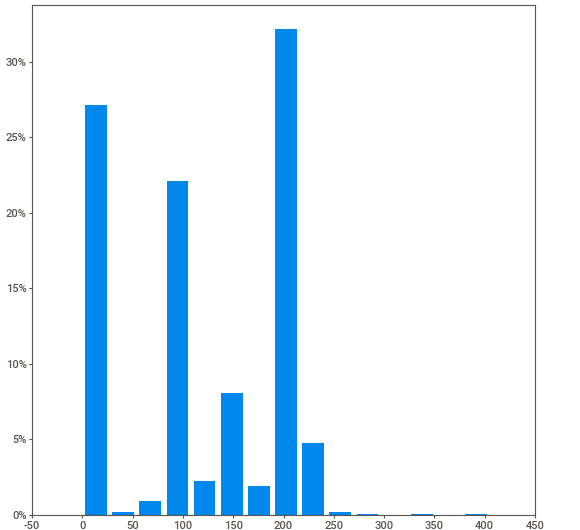
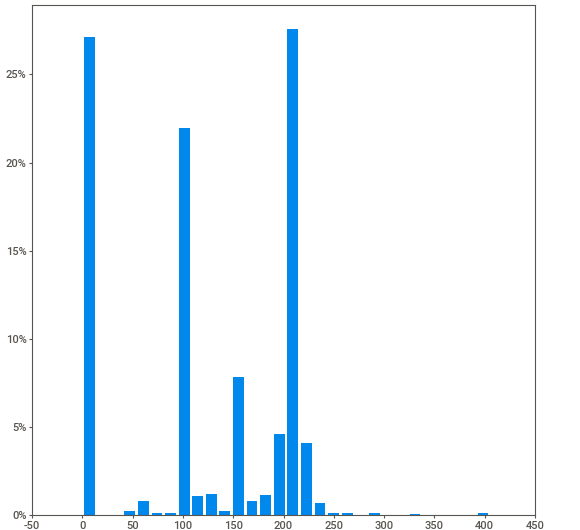
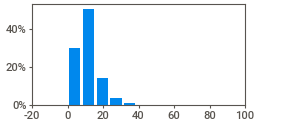
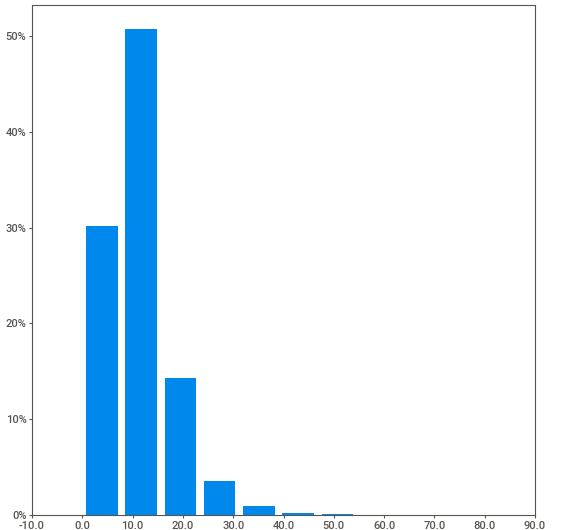
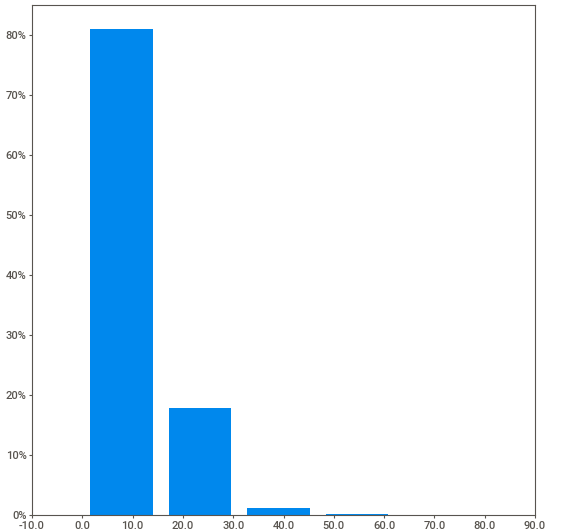
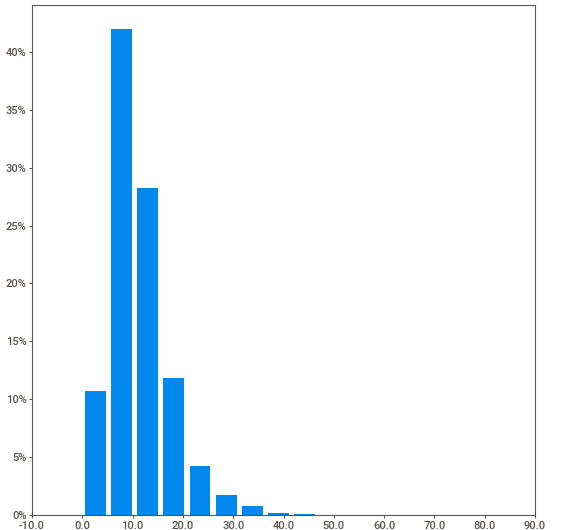
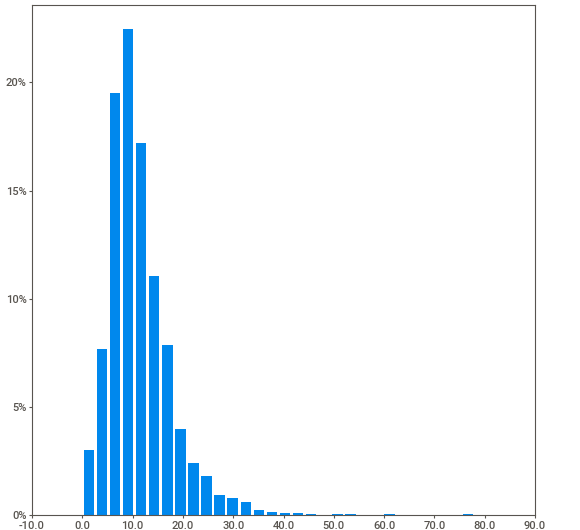
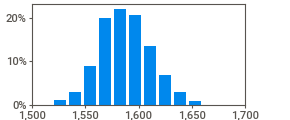
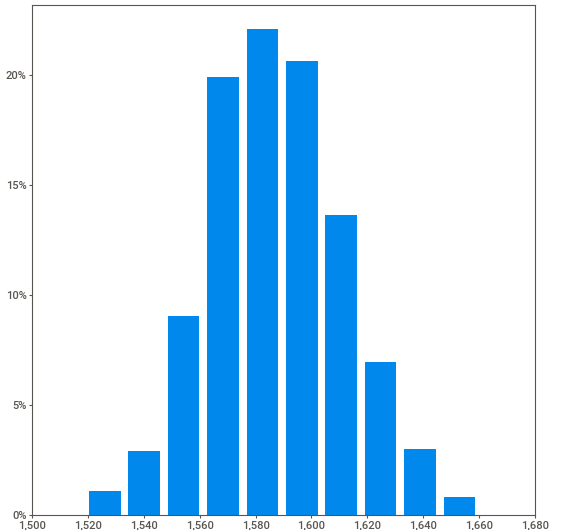
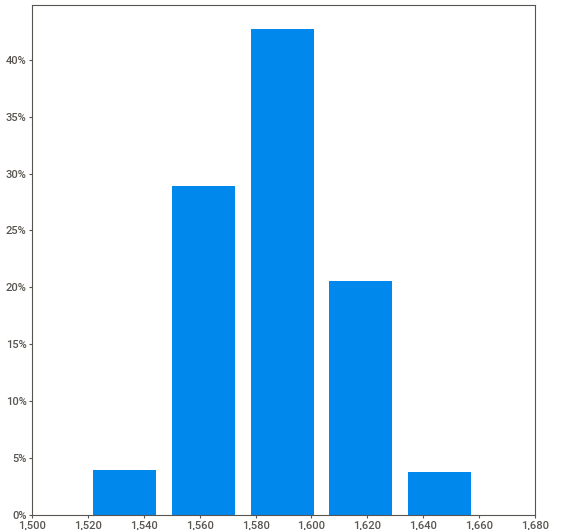
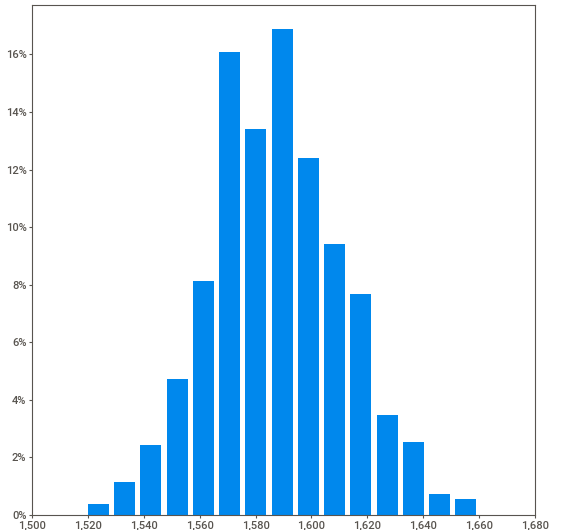
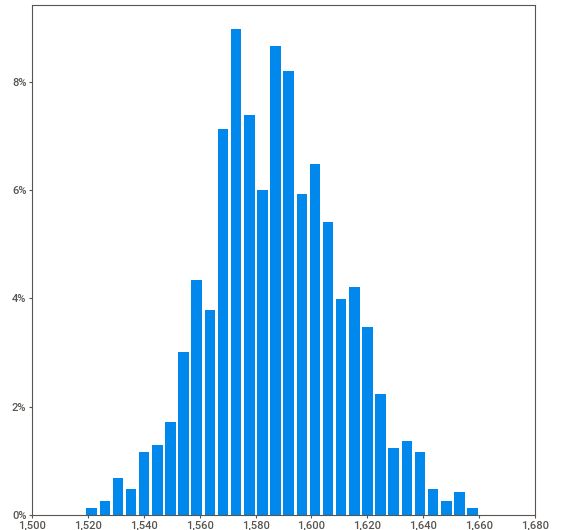
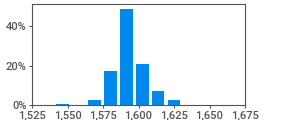
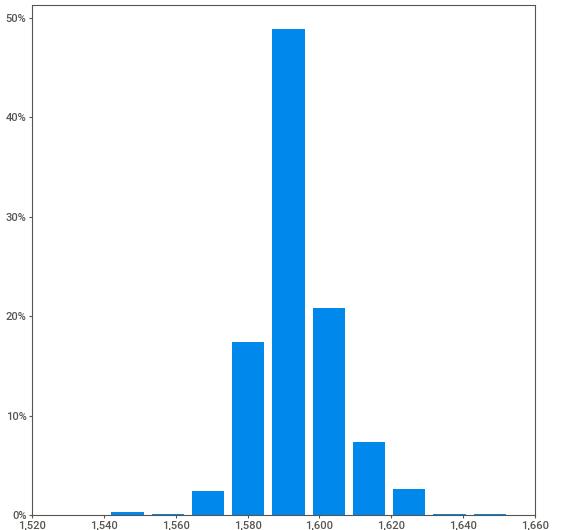
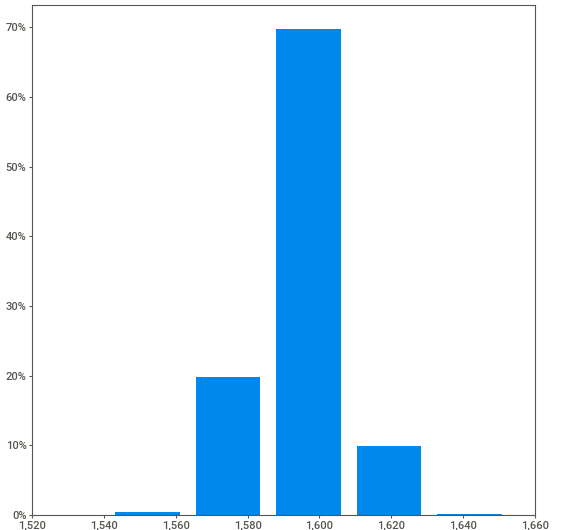
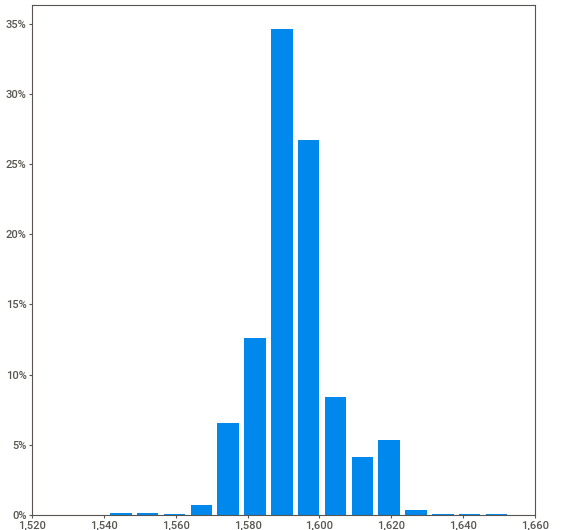
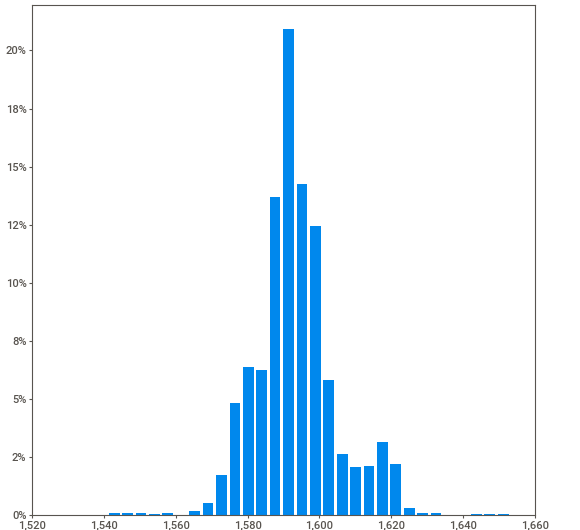
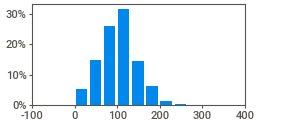
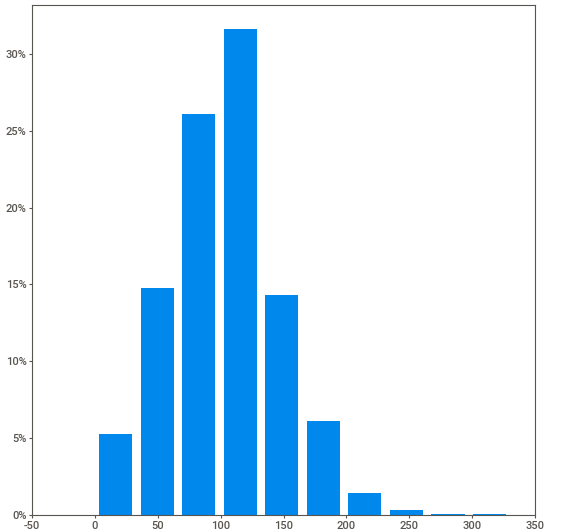
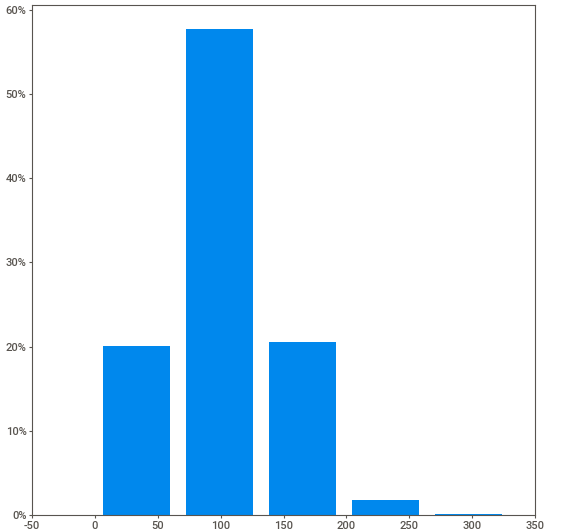
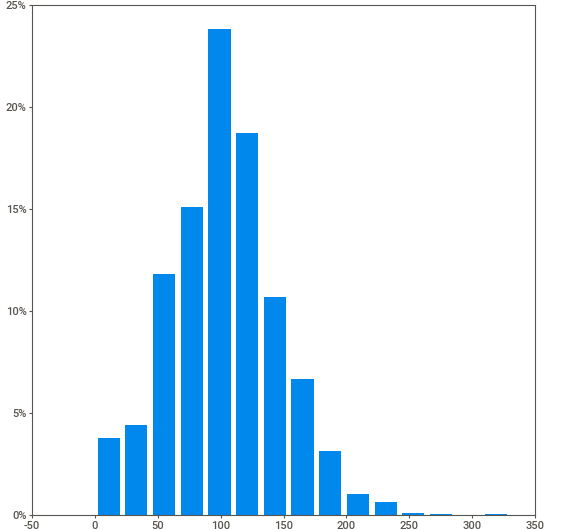
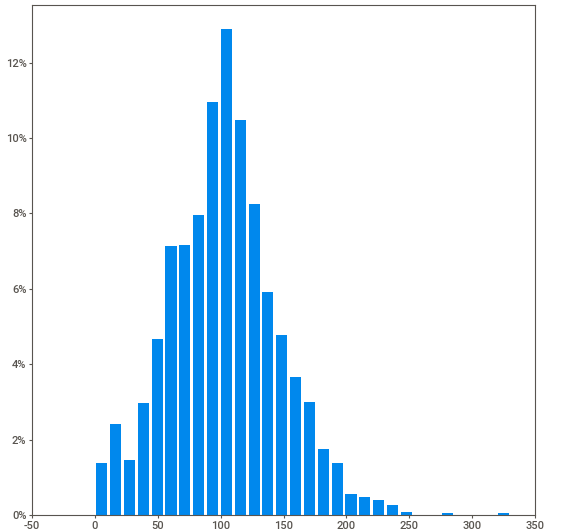
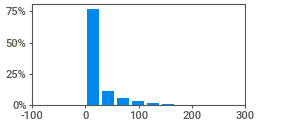
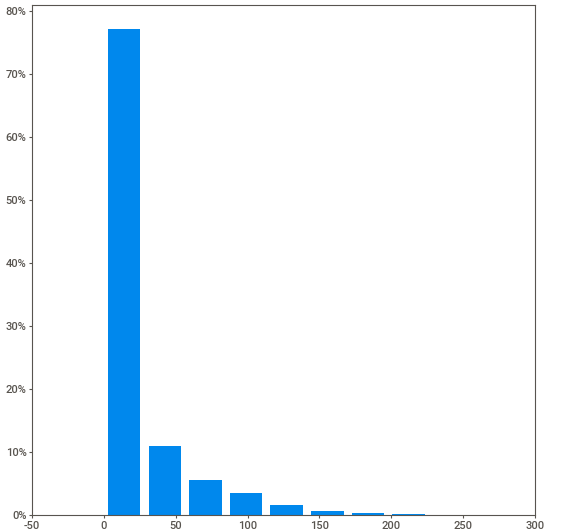
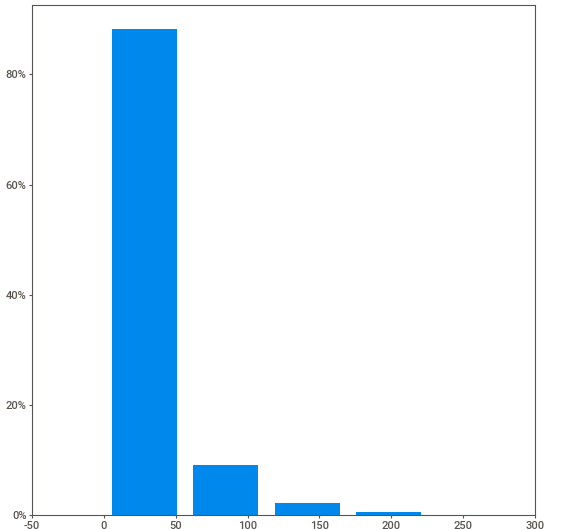
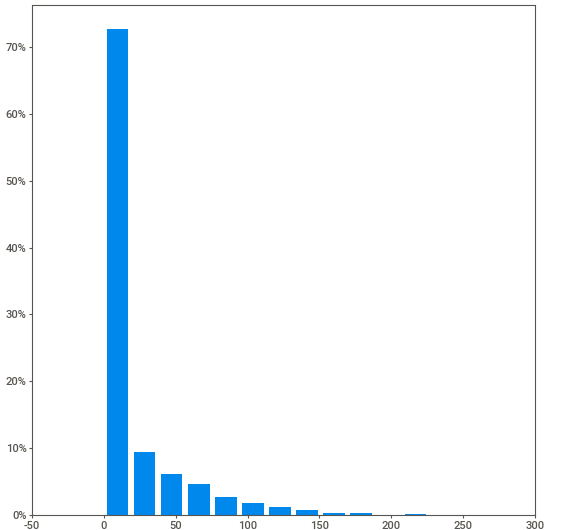
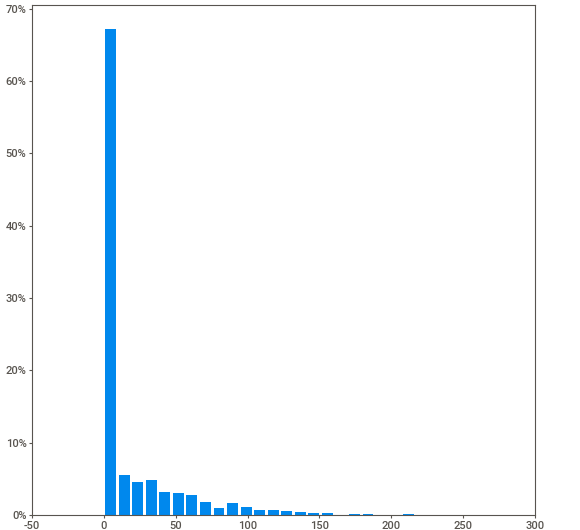
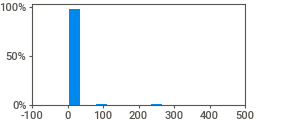
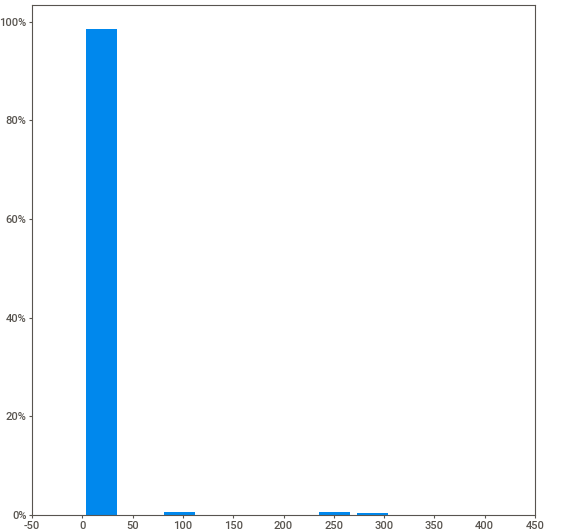
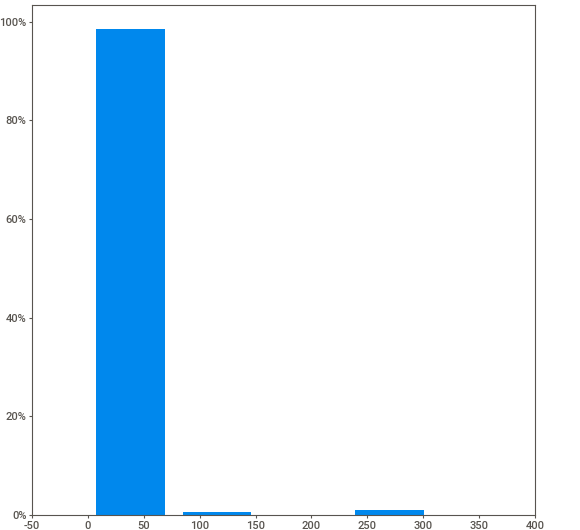
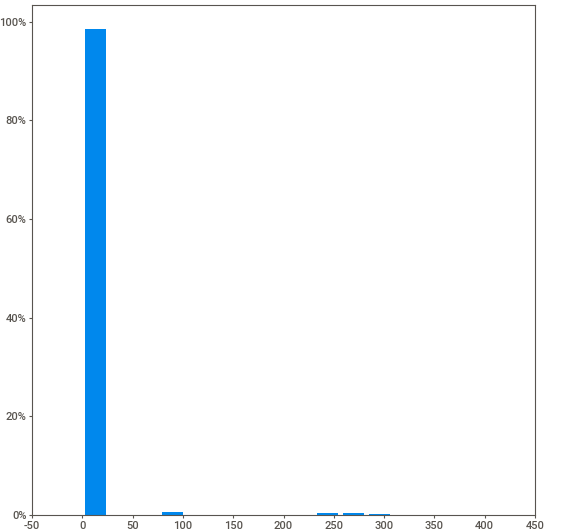
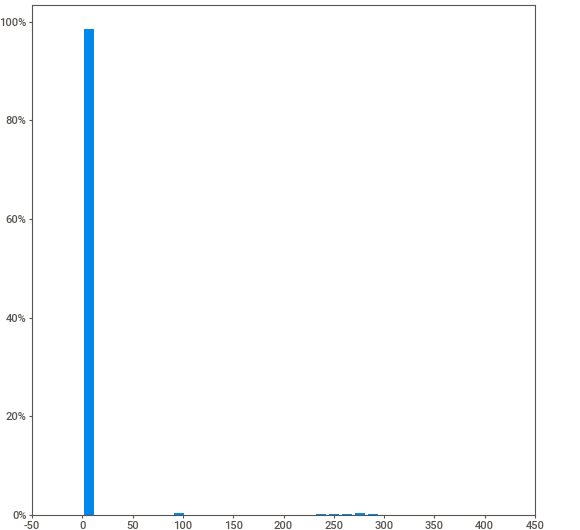
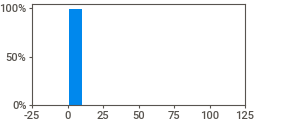
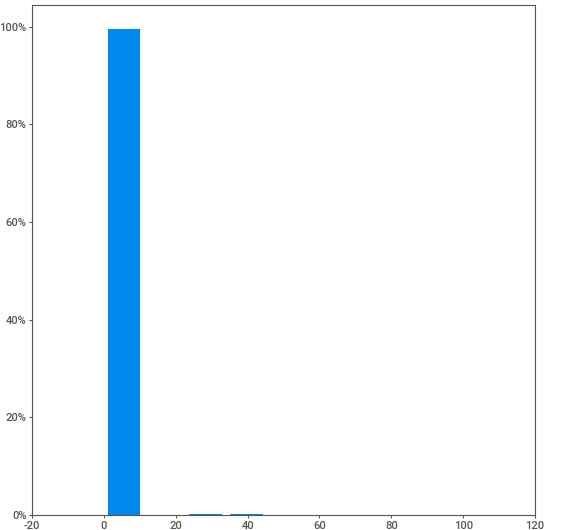
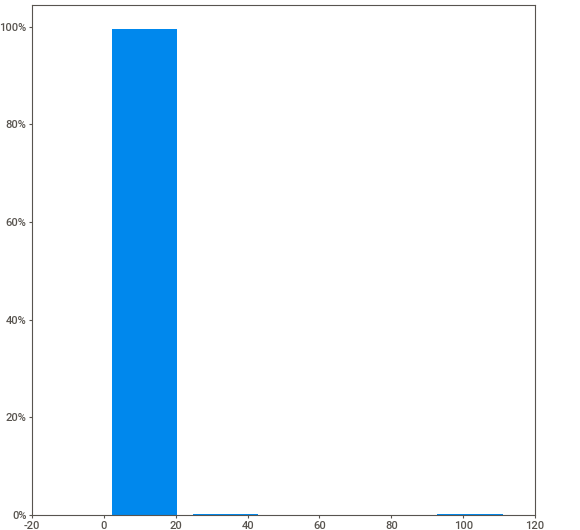
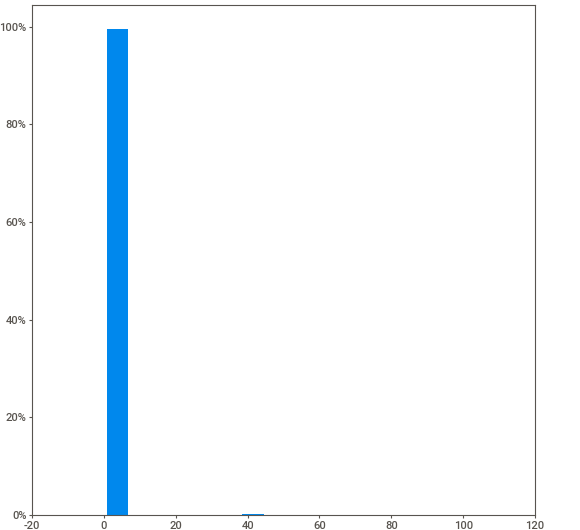
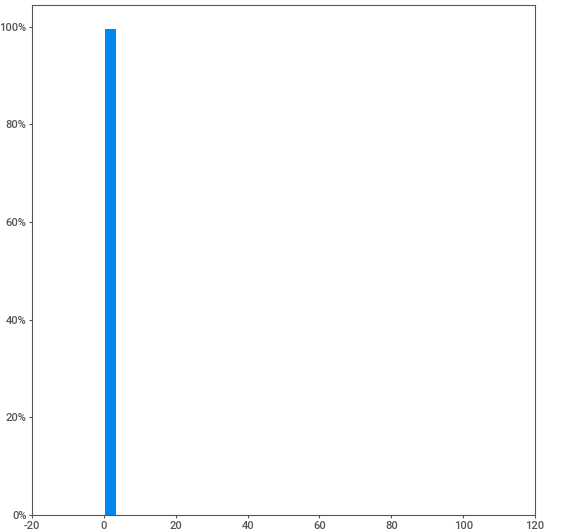
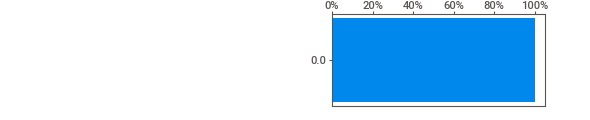
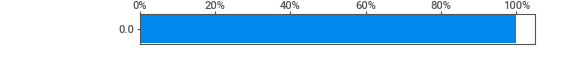
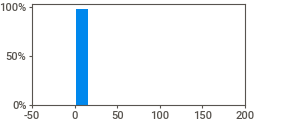
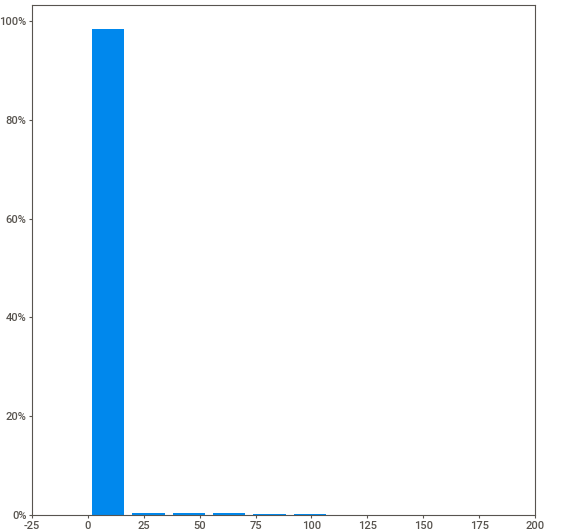
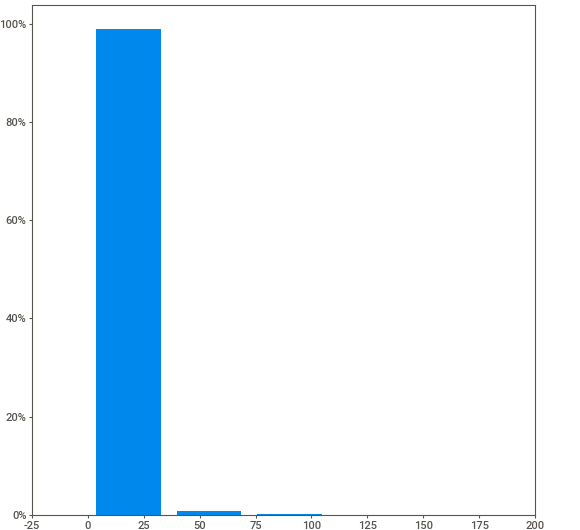
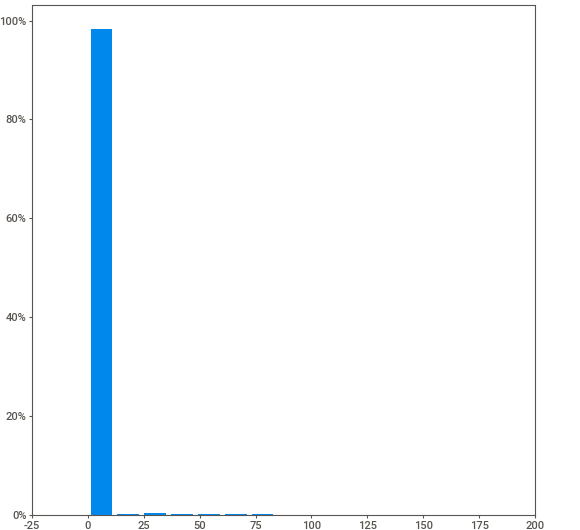
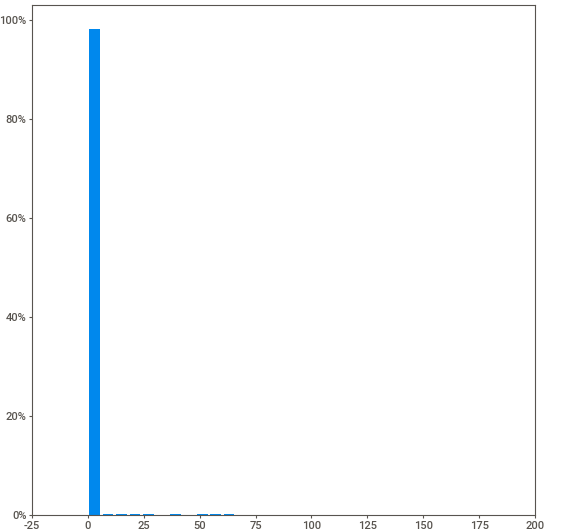
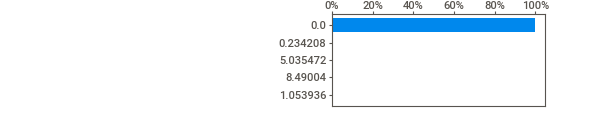
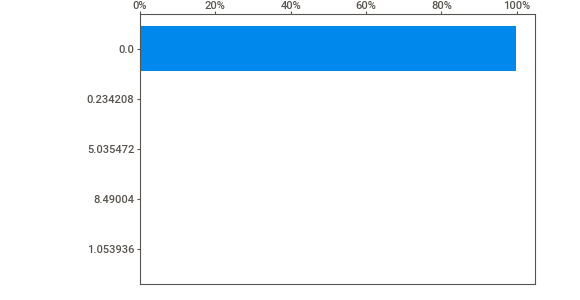
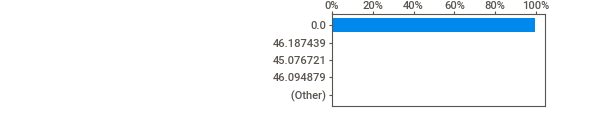
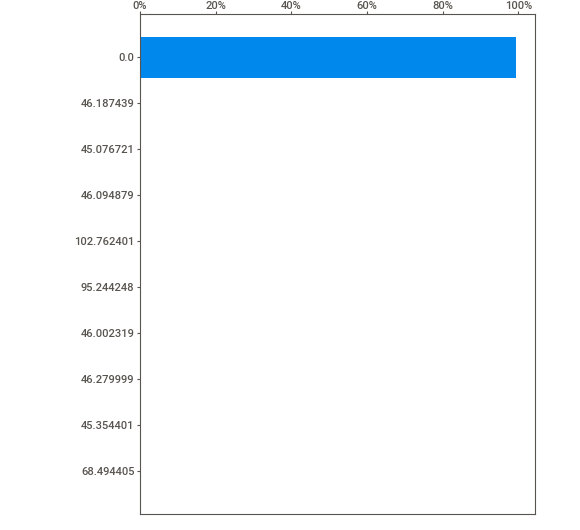
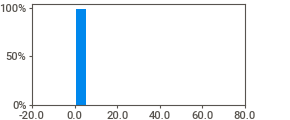
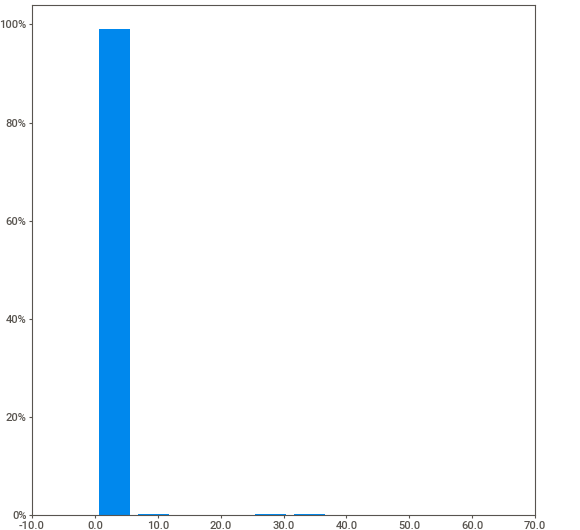
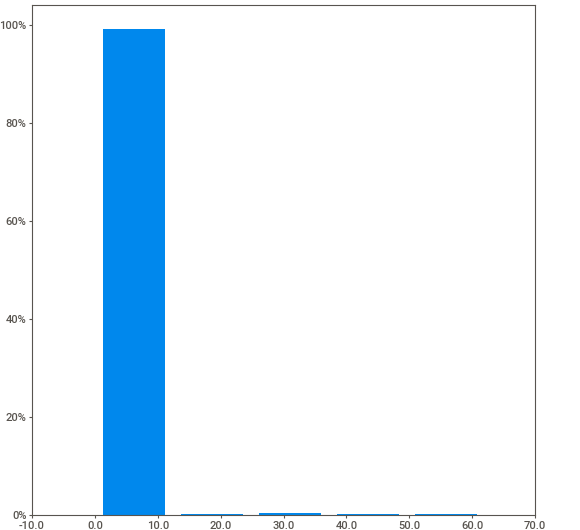
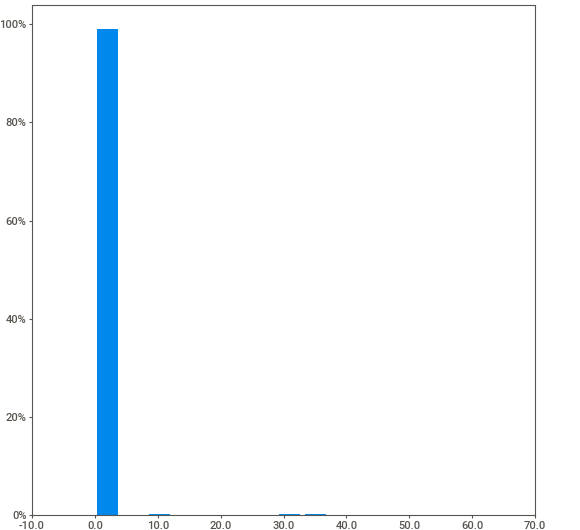
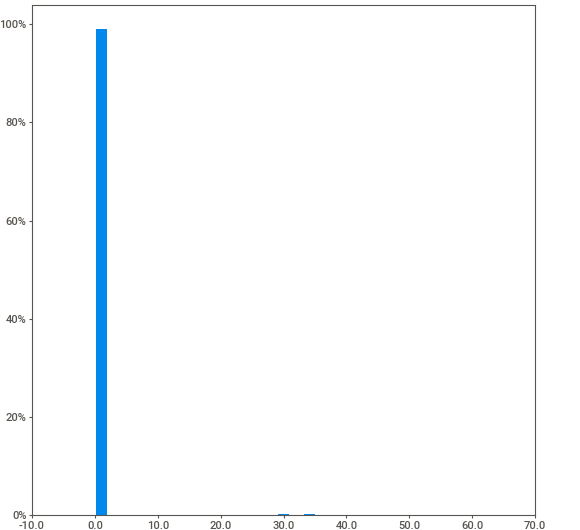
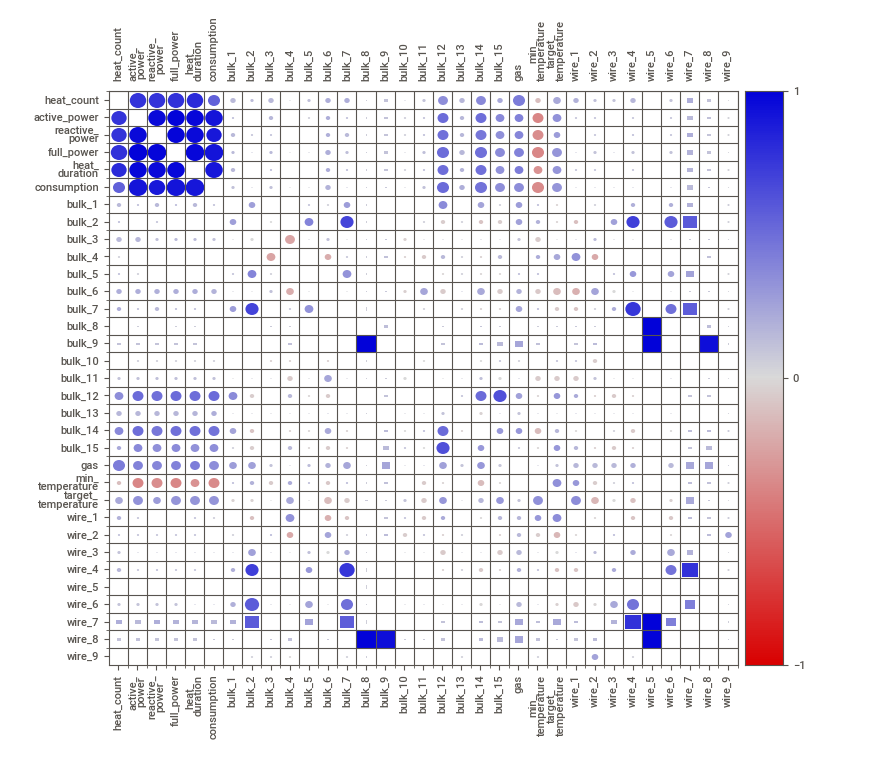
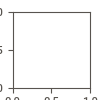

In [62]:
report = sv.analyze(df)
report.show_notebook(w=None, h=None, scale=0.9, layout='widescreen', filepath=None)

Из графиков распределения видно, что все фичи из таблицы с нагревом, газом, температурой, а также 14-й сыпучий материал и первый проволочный имеют нормальное или гамма- распределение стремящееся к нормальному. Все же остальные признаки тяготеют к нулю, т.к. это связано с недобавляющимися сыпучими или проволочными материалами.

interval columns not set, guessing: ['heat_count', 'active_power', 'reactive_power', 'full_power', 'heat_duration', 'consumption', 'bulk_1', 'bulk_2', 'bulk_3', 'bulk_4', 'bulk_5', 'bulk_6', 'bulk_7', 'bulk_8', 'bulk_9', 'bulk_10', 'bulk_11', 'bulk_12', 'bulk_13', 'bulk_14', 'bulk_15', 'gas', 'min_temperature', 'target_temperature', 'wire_1', 'wire_2', 'wire_3', 'wire_4', 'wire_5', 'wire_6', 'wire_7', 'wire_8', 'wire_9']


C:\Users\User\practicum\practicum_env\lib\site-packages\phik\data_quality.py:72: UserWarning: Not enough unique value for variable wire_5 for analysis 1. Dropping this column
  warnings.warn(


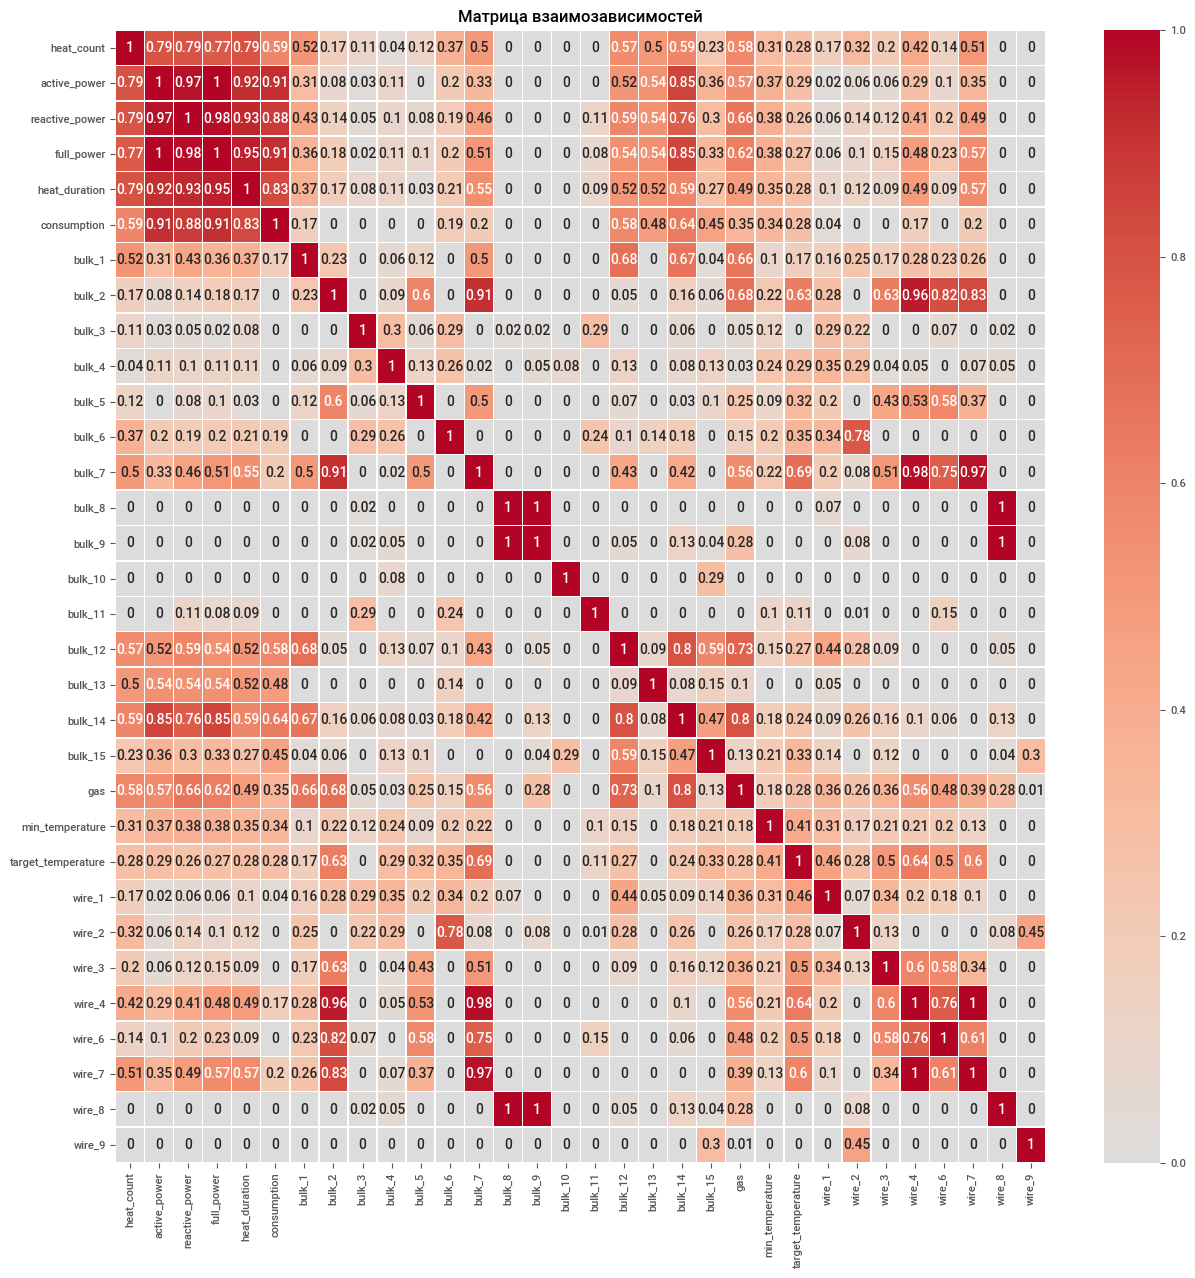

In [63]:
phik_overview = df.phik_matrix()
plt.figure(figsize=(15, 15))
corr_matrix = phik_overview
corr_matrix = np.round(corr_matrix, 2)
sns.heatmap(corr_matrix, annot=True, linewidth= 0.3, cmap='coolwarm', center=0)
plt.title('Матрица взаимозависимостей')
plt.show()

Из матрицы зависимостей видим, что вновь созданные признаки коррелируют с теми, из которых они были созданы, что логично.

Также стоит отметить стопроцентную корреляцию признаков `wire_8` с `bulk_8` и `bulk_9`, а также `bulk_8` и `bulk_9` между собой, при этом они не оказывают никакого влияния на целевую переменную, поэтому два из них можем удалить.

Уже сейчас по данной матрице можем увидеть топ-4 главных признака, оказывающих влияние на целевой, это: минимальная температура, 7-й сыпучий материал, 1-й и 4-й проволочные материалы.

In [64]:
df = df.drop(['wire_8', 'bulk_8'], axis=1)

## 4. Подготовка данных для обучения

In [65]:
X = df.drop('target_temperature', axis=1)
y = df['target_temperature']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=RANDOM_STATE)

In [66]:
X_train.shape, X_test.shape

((1746, 30), (583, 30))

Видим, что в обучающей выборке 1746 строк, что соответстует требованию заказчика. В тестовой получилось 583 строки.

Все признаки в нашем наборе данных количественные, выполним их масштабирование.

In [67]:
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train),
                              columns=X_train.columns,
                              index=X_train.index)
X_test = pd.DataFrame(scaler.transform(X_test),
                             columns=X_test.columns,
                             index=X_test.index)

Далее можем перейти к обучению моделей.

## 5. Обучение моделей

Обучим несколько моделей: случайный лес, CatBoost и нейронную сеть. Сравним результаты.

### **Случайный лес**

In [68]:
forest = RandomForestRegressor(random_state=RANDOM_STATE)

In [69]:
forest_params = {
    'n_estimators': range(40, 200, 20),
    'max_depth': range(9, 15),
    'random_state': [RANDOM_STATE]
}

In [70]:
gsc_forest = GridSearchCV(forest, forest_params, scoring='neg_mean_absolute_error', n_jobs=-1, cv=5)

In [71]:
gsc_forest.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=60624),
             n_jobs=-1,
             param_grid={'max_depth': range(9, 15),
                         'n_estimators': range(40, 200, 20),
                         'random_state': [60624]},
             scoring='neg_mean_absolute_error')

In [72]:
gsc_forest.best_params_

{'max_depth': 10, 'n_estimators': 60, 'random_state': 60624}

In [73]:
-gsc_forest.best_score_

5.934426554127631

### **CatBoost**

In [74]:
params = [{
          'learning_rate':[0.01, 0.05],
          'l2_leaf_reg':[1,8],
          'depth':[3,6]
          }]

In [75]:
cbr = CatBoostRegressor(early_stopping_rounds=100,
                        grow_policy='Depthwise',
                        depth=3,
                        loss_function='RMSE',
                        random_state=RANDOM_STATE,
                        l2_leaf_reg=1,
                        learning_rate=0.01,
                        verbose=10,
                        eval_metric='MAE')

In [76]:
gsc_cbr = GridSearchCV(cbr, params, scoring='neg_mean_absolute_error', n_jobs=-1, cv=5)

In [77]:
gsc_cbr.fit(X_train, y_train)

0:	learn: 8.0769438	total: 59.5ms	remaining: 59.5s
10:	learn: 7.8139296	total: 139ms	remaining: 12.5s
20:	learn: 7.5639363	total: 199ms	remaining: 9.29s
30:	learn: 7.3413171	total: 264ms	remaining: 8.25s
40:	learn: 7.1418873	total: 328ms	remaining: 7.66s
50:	learn: 6.9616663	total: 391ms	remaining: 7.27s
60:	learn: 6.7980865	total: 450ms	remaining: 6.93s
70:	learn: 6.6571014	total: 513ms	remaining: 6.71s
80:	learn: 6.5168781	total: 577ms	remaining: 6.55s
90:	learn: 6.3952429	total: 639ms	remaining: 6.39s
100:	learn: 6.2756019	total: 701ms	remaining: 6.24s
110:	learn: 6.1674803	total: 764ms	remaining: 6.12s
120:	learn: 6.0631876	total: 825ms	remaining: 5.99s
130:	learn: 5.9664521	total: 887ms	remaining: 5.88s
140:	learn: 5.8799762	total: 947ms	remaining: 5.77s
150:	learn: 5.7989974	total: 1.01s	remaining: 5.67s
160:	learn: 5.7282709	total: 1.07s	remaining: 5.57s
170:	learn: 5.6630612	total: 1.13s	remaining: 5.47s
180:	learn: 5.5961102	total: 1.19s	remaining: 5.39s
190:	learn: 5.5352942	

GridSearchCV(cv=5,
             estimator=<catboost.core.CatBoostRegressor object at 0x0000020E05855A00>,
             n_jobs=-1,
             param_grid=[{'depth': [3, 6], 'l2_leaf_reg': [1, 8],
                          'learning_rate': [0.01, 0.05]}],
             scoring='neg_mean_absolute_error')

In [78]:
gsc_cbr.best_params_

{'depth': 6, 'l2_leaf_reg': 1, 'learning_rate': 0.01}

In [79]:
-gsc_cbr.best_score_

5.807744554889801

### **Нейронная сеть**

In [80]:
model = Sequential()
model.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],)))
model.add(BatchNormalization())
model.add(Dropout(0.3))
model.add(Dense(256, activation='relu'))
model.add(BatchNormalization())
#model.add(Dropout(0.2))
model.add(Dense(32, activation='relu'))
#model.add(BatchNormalization())
#model.add(Dropout(0.3))
model.add(Dense(1, activation='relu'))

In [81]:
optimizer = Adam(learning_rate=0.0001)
model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

In [82]:
nn = model.fit(X_train, y_train, epochs=6000, verbose=2)

Epoch 1/6000
55/55 - 1s - loss: 2536359.7500 - mae: 1592.5552 - 743ms/epoch - 14ms/step
Epoch 2/6000
55/55 - 0s - loss: 2533308.0000 - mae: 1591.5966 - 82ms/epoch - 1ms/step
Epoch 3/6000
55/55 - 0s - loss: 2528881.0000 - mae: 1590.2054 - 85ms/epoch - 2ms/step
Epoch 4/6000
55/55 - 0s - loss: 2522827.7500 - mae: 1588.3011 - 89ms/epoch - 2ms/step
Epoch 5/6000
55/55 - 0s - loss: 2515046.0000 - mae: 1585.8485 - 86ms/epoch - 2ms/step
Epoch 6/6000
55/55 - 0s - loss: 2505342.5000 - mae: 1582.7815 - 84ms/epoch - 2ms/step
Epoch 7/6000
55/55 - 0s - loss: 2492832.0000 - mae: 1578.8165 - 85ms/epoch - 2ms/step
Epoch 8/6000
55/55 - 0s - loss: 2477413.7500 - mae: 1573.9091 - 86ms/epoch - 2ms/step
Epoch 9/6000
55/55 - 0s - loss: 2458781.0000 - mae: 1567.9556 - 86ms/epoch - 2ms/step
Epoch 10/6000
55/55 - 0s - loss: 2437864.5000 - mae: 1561.2340 - 86ms/epoch - 2ms/step
Epoch 11/6000
55/55 - 0s - loss: 2413351.7500 - mae: 1553.3236 - 89ms/epoch - 2ms/step
Epoch 12/6000
55/55 - 0s - loss: 2387570.2500 - ma

Лучше всех себя показала нейронная сеть, но она, очевидно, переобучилась, поэтому в качестве лучшей возьмем модель CatBoost, с MAE равным 5,81. Далее проверим модель на тестовой выборке.

## 6. Тестирование лучшей модели

In [83]:
best_model = gsc_cbr.best_estimator_

In [84]:
preds = best_model.predict(X_test)

In [85]:
mae = mean_absolute_error(preds, y_test)
mae

5.9314705843028985

Получили значение MAE равное 5,93, что соответствует требованию заказчика.

Далее рассчитаем метрику для константной модели.

In [86]:
dummy_regr = DummyRegressor(strategy="mean")
dummy_regr.fit(X_train, y_train)

DummyRegressor()

In [87]:
dummy_regr_preds = dummy_regr.predict(X_test)

In [88]:
dummy_regr_mae = mean_absolute_error(dummy_regr_preds, y_test)
dummy_regr_mae

8.11157185549326

Получившееся на нашей лучшей модели значение практически на 2 пункта лучше, чем предсказания константной модели.

In [89]:
r2 = r2_score(preds, y_test)
r2

-0.16517069205592216

R2 меньше нуля, но близок к нему, что говорит о том, что выбранный метод прогнозирования является слабым. Реальное значение температуры достаточно близко к среднему значению, что видно при сравнении лучшей и случайной моделей.

 Далее посмотрим 10 самых важных признаков.

In [90]:
importances = best_model.feature_importances_
feature_list = list(X_test.columns)
feature_results = pd.DataFrame({'feature': feature_list,'importance': importances})
feature_results = feature_results.sort_values('importance',ascending = False).reset_index(drop=True)

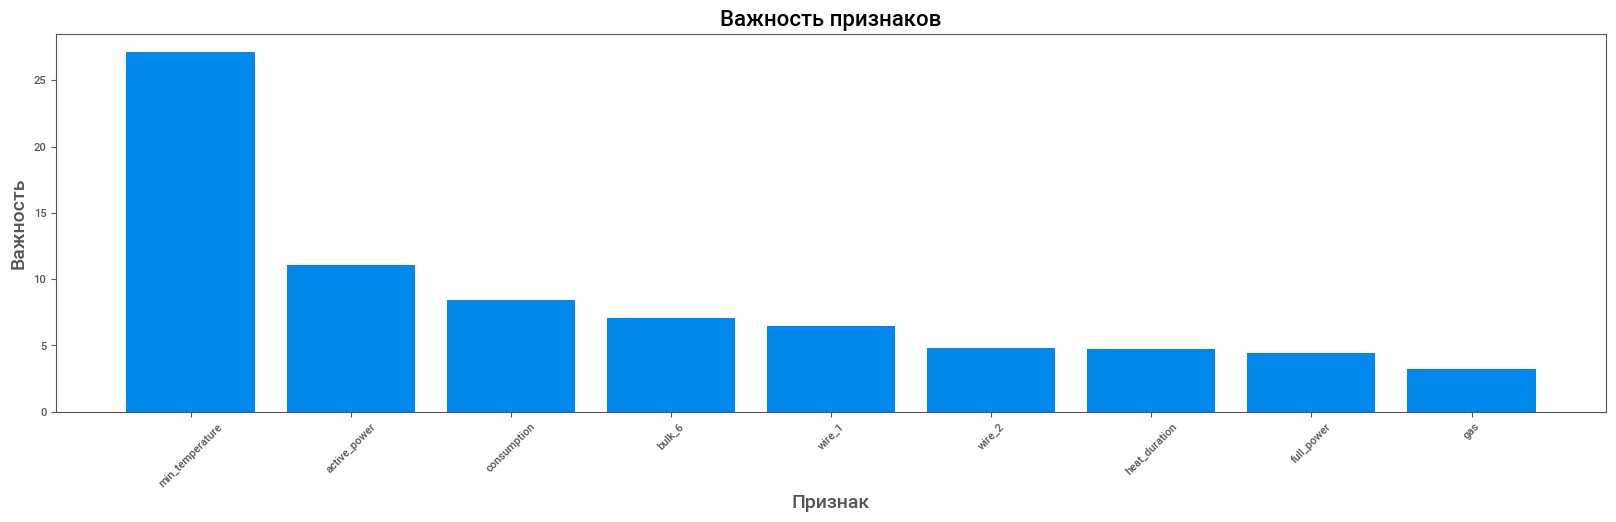

In [91]:
height = feature_results['importance'][0:9]
bars = feature_results['feature'][0:9]
y_pos = np.arange(len(bars))

plt.figure(figsize=(20,5))
plt.bar(y_pos, height)
plt.xticks(y_pos, bars, rotation=45)
plt.title('Важность признаков', fontsize=16)
plt.xlabel('Признак', fontsize=14)
plt.ylabel('Важность', fontsize=14)
plt.show()

Из графика видим, что наиболее важным признаком является минимальная температура, после чего с некоторым разрывом следуют данные, связанные с нагревом(в том числе вновь созданные нами признаки). Рассмотрим зависимость целевой температуры от добавления первого проволочного материала.

<AxesSubplot:xlabel='wire_1', ylabel='target_temperature'>

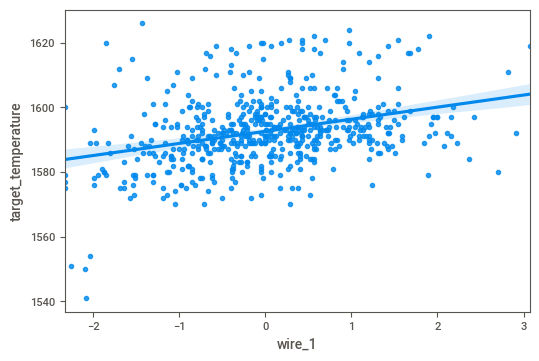

In [92]:
sns.regplot(x=X_test["wire_1"], y=y_test)

Видим, что наблюдается некоторая положительная корреляция. Имеется тенденция к тому, что, чем больше добавляется первого проволочного материала, тем выше температура сплава.

## 7. Общий вывод

Успешно подключились к серверу и смогли получить названия всех таблиц, их количество и название соответствует представленным в описании.

На основе данных об электродах создали новые признаки:
- продолжительность нагрева
- количество запусков нагрева электродами;
- полную мощность, которая равна квадратному корню из суммы квадратов активной и реактивной мощностей: $ S = sqrt(P^2 + Q^2) $
- потребление электроэнергии, равное произведению полной мощности на время нагрева.

Обработали все таблицы с данными на предмет пропусков, выбросов и аномалий.

Обработанный и окончательный датафрейм уменьшился по сравнению с первоначальным на 24,41%. Потеряли ощутимое количество данных, но получившийся набор должен с большим качеством обучить модель.

Рассмотрели графики распределения признаков, из которых увидели, что все фичи из таблицы с нагревом, газом, температурой, а также 14-й сыпучий материал и первый проволочный имеют нормальное или гамма- распределение стремящееся к нормальному. Все же остальные признаки тяготеют к нулю, т.к. это связано с недобавляющимися сыпучими или проволочными материалами.

Далее построили матрицу зависимостей. Вновь созданные признаки коррелируют с теми, из которых они были созданы, что логично.

Также стоит отметить стопроцентную корреляцию признаков `wire_8` с `bulk_8` и `bulk_9`, а также `bulk_8` и `bulk_9` между собой, при этом они не оказывают никакого влияния на целевую переменную, поэтому два из них удалили.

После чего обучили несколько моделей: случайный лес, CatBoost и нейронную сеть. Лучше всего себя показал CatBoost, выполнили его проверку на тестовых данных и получили значение MAE равное 5,93, что примерно на 2 пункта лучше, чем значение метрики полученное константной моделью.

Дополнительно рассчитали метрику R2, которая оказаласьнуля, но близок к нему, что говорит о том, что выбранный метод прогнозирования является слабым. Реальное значение температуры достаточно близко к среднему значению, что видно при сравнении лучшей и случайной моделей.

Рассмотрели важность признаков для нашей лучшей модели. Наиболее важным признаком является минимальная температура, после чего с некоторым разрывом следуют данные, связанные с нагревом(в том числе вновь созданные нами признаки).

Пронаблюдали зависимость целевой температуры от добавления первого проволочного материала. Определили, что имеется тенденция к тому, что, чем больше добавляется первого проволочного материала, тем выше температура сплава.

Заказчику рекомендуется улучшить точность замера температуры, т.к. она является важным признаком для прогнозирования, а также обратить внимание на данные об электродах, на основе которых мы синтезировали немало важных признаков. Можно добавить больше замеров параметров, т.к. это будет точнее, чем полученные расчетом признаки.